# Neural Regression Monte Carlo for the Harvesting Problem

**Author:** Aurélien Grenard

This notebook implements a neural Regression Monte Carlo approach for the multidimensional harvesting impulse control problem. It contains the training, evaluation and visualization procedures used in the accompanying numerical experiments.

## Citation

If you use this code, results or figures in academic work, please cite the corresponding article and acknowledge the original implementation.

## License

This code is provided for research and educational purposes. Redistribution and modification are permitted provided that appropriate credit is given to the original author.

## Environment

The experiments were conducted with:

```text
Python      3.11.2
PyTorch     2.3.1
CUDA        12.1
Matplotlib  3.10.8
NumPy       2.4.4
```

A compatible Conda environment can be created with:

```bash
conda create -n ImpulseControl python=3.11
conda activate ImpulseControl

conda install pytorch=2.3.1 pytorch-cuda=12.1 matplotlib numpy -c pytorch -c nvidia
```

In [19]:
from __future__ import annotations

import os
import sys
import math

from dataclasses import dataclass, field, asdict, is_dataclass
from typing import Any, Callable, Optional, Tuple, List, Dict, Union

import torch
import torch.nn as nn

import matplotlib
import matplotlib.pyplot as plt

import numpy as np

print("Python :", sys.version)
print("PyTorch :", torch.__version__)
print("CUDA :", torch.version.cuda)
print("Matplotlib :", matplotlib.__version__)
print("NumPy :", np.__version__)
print("CUDA available :", torch.cuda.is_available())

Python : 3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
PyTorch : 2.3.1+cu121
CUDA : 12.1
Matplotlib : 3.10.8
NumPy : 2.4.4
CUDA available : True


## Exact solution

Implementation of the exact $(\hat{x},x^\ast)$ band policy for the harvesting problem without jumps, following Chapter 6 of Øksendal and Sulem, *Applied Stochastic Control of Jump Diffusions*.

The code computes the optimal thresholds $\hat{x}$ and $x^\ast$, the value function $\psi$, and the associated optimal impulse policy.

In [20]:
torch.set_default_dtype(torch.float64)
# ------------------------- helpers: coefficients -------------------------

def _coefficients(mu: float, sigma: float, rho: float, alpha: float, x0: float):
    """Compute A, B, C, r1 for the general case."""
    assert rho > 0.0 and sigma > 0.0 and alpha > 0.0, "Require rho>0, sigma>0, alpha>0."
    A = alpha / rho
    B = (2.0 * alpha / (rho * rho)) * (mu - rho * x0)
    C = (sigma * sigma * A + mu * B + alpha * x0 * x0) / rho
    disc = mu * mu + 2.0 * rho * sigma * sigma
    r1 = (-mu + math.sqrt(disc)) / (sigma * sigma)  # positive root
    return A, B, C, r1

# ------------------------- inner solver: d given x_hat -------------------------

def _solve_d_given_xhat(x_hat: float, A: float, B: float, r1: float, lam: float, c: float,
                        tol: float = 1e-12, itmax: int = 200) -> float:
    """
    Solve (Bgen):  2 x_hat + d = 2/r1 - (B - λ)/A + (c)/(A d), for d>0.
    Define T(d) = 2 x_hat + d - [2/r1 - (B - λ)/A] - c/(A d) = 0.
    T is strictly increasing on (0, +∞); bisection is robust.
    """
    const = (2.0 / r1) - (B - lam) / A

    def T(d: float) -> float:
        return 2.0 * x_hat + d - const - (c / (A * d))

    # Bracket: as d -> 0+, T(d) -> -∞ ; as d -> +∞, T(d) -> +∞
    dL = 1e-14
    dR = 1.0
    while T(dR) < 0.0:
        dR *= 2.0
        if dR > 1e12:
            raise RuntimeError("Failed to bracket d. Check parameters (A,B,r1,c,λ) or try different seeds.")

    # Bisection
    for _ in range(itmax):
        dm = 0.5 * (dL + dR)
        val = T(dm)
        if abs(val) < tol or abs(dR - dL) < tol:
            return dm
        if val < 0.0:
            dL = dm
        else:
            dR = dm
    return 0.5 * (dL + dR)

# ------------------------- outer residual in x_hat -------------------------

def _outer_residual(x_hat: float, A: float, B: float, r1: float, lam: float, c: float) -> float:
    """
    Outer residual: (Agen) after eliminating d via (Bgen).
      (2A x_hat + B - λ) e^{-r1 x_hat} = (2A(x_hat+d) + B - λ) e^{-r1 (x_hat + d)}
    Returns lhs - rhs.
    """
    d = _solve_d_given_xhat(x_hat, A, B, r1, lam, c, tol=1e-13)
    x_star = x_hat + d
    lhs = (2.0 * A * x_hat + B - lam) * math.exp(-r1 * x_hat)
    rhs = (2.0 * A * x_star + B - lam) * math.exp(-r1 * x_star)
    return lhs - rhs

# ------------------------- core solver -------------------------

def _solve_band_general(mu: float, sigma: float, rho: float, alpha: float, x0: float,
                        lam: float, c: float, tol: float = 1e-12, itmax: int = 200):
    """
    Solve for (x_hat, x_star, a) in the general diffusion case (no jumps).
    Uses nested bisection: d|x_hat via (Bgen), then x_hat via (Agen).
    """
    assert c > 0.0 and lam >= 0.0, "Require c>0 and λ>=0."
    A, B, C, r1 = _coefficients(mu, sigma, rho, alpha, x0)

    # Bracket x_hat for outer residual (Agen)
    xL = 1e-12
    xR = max(1e-3, 0.5 * lam * (rho if rho > 0 else 1.0) + math.sqrt(abs(c) / (alpha if alpha > 0 else 1.0)) + abs(x0))
    fL = _outer_residual(xL, A, B, r1, lam, c)
    fR = _outer_residual(xR, A, B, r1, lam, c)

    expand = 0
    while fL * fR > 0.0 and expand < 60:
        xR *= 2.0
        fR = _outer_residual(xR, A, B, r1, lam, c)
        expand += 1
    if fL * fR > 0.0:
        raise RuntimeError("Failed to bracket x_hat; try different parameters (ρ,λ,c) or initial bounds.")

    # Bisection on x_hat
    for _ in range(itmax):
        xm = 0.5 * (xL + xR)
        fm = _outer_residual(xm, A, B, r1, lam, c)
        if abs(fm) < tol or abs(xR - xL) < tol:
            x_hat = xm
            break
        if fL * fm <= 0.0:
            xR, fR = xm, fm
        else:
            xL, fL = xm, fm
    else:
        x_hat = 0.5 * (xL + xR)

    # Recover d, x_star, a
    d = _solve_d_given_xhat(x_hat, A, B, r1, lam, c, tol=1e-13)
    x_star = x_hat + d
    a = ((2.0 * A * x_star + B - lam) / r1) * math.exp(-r1 * x_star)

    return x_hat, x_star, a, (A, B, C, r1)

# ------------------------- public API -------------------------

def solve_psi_general(mu: float, sigma: float, rho: float, alpha: float, x0: float,
                      lam: float, c: float):
    """
    Build ψ, ζ* for the general diffusion case (no jumps).
    Returns:
        psi (callable: torch.Tensor -> torch.Tensor),
        zeta_star (callable: torch.Tensor -> torch.Tensor),
        params (dict)
    """
    x_hat, x_star, a, (A, B, C, r1) = _solve_band_general(mu, sigma, rho, alpha, x0, lam, c)
    # Precompute ψ0(x_hat)
    psi0_xhat = (A * x_hat * x_hat + B * x_hat + C) - a * math.exp(r1 * x_hat)

    def psi(x: torch.Tensor) -> torch.Tensor:
        """Piecewise ψ: inaction vs action."""
        x = x.to(dtype=torch.get_default_dtype())
        psi_p = A * x * x + B * x + C
        val_inact = psi_p - a * torch.exp(torch.tensor(r1) * x)
        val_act = torch.full_like(x, psi0_xhat) + c + lam * (x - x_hat)
        return torch.where(x < x_star, val_inact, val_act)

    def zeta_star(x: torch.Tensor) -> torch.Tensor:
        """Optimal impulse size: jump down to x_hat."""
        x = x.to(dtype=torch.get_default_dtype())
        return torch.clamp(x - x_hat, min=0.0)

    params = {
        "x_hat": x_hat,
        "x_star": x_star,
        "a": a,
        "r1": r1,
        "A": A, "B": B, "C": C,
        "mu": mu, "sigma": sigma, "rho": rho, "alpha": alpha, "x0": x0,
        "lam": lam, "c": c,
    }
    return psi, zeta_star, params

# ------------------------- plotting utility -------------------------

def plot_psi_general(mu: float, sigma: float, rho: float, alpha: float, x0: float,
                     lam: float, c: float,
                     x_min: float = 0.0, x_max: float = 5.0, n_points: int = 1201,
                     show: bool = True, save_path: str | None = None):
    """
    Plot ψ(x) over [x_min, x_max] with vertical markers at x_hat and x_star.
    Uses matplotlib (no seaborn); single figure; no explicit colors.
    """
    psi, zeta, p = solve_psi_general(mu, sigma, rho, alpha, x0, lam, c)
    print(f"psi(1) = {psi(torch.ones(1))}")
    xs = torch.linspace(x_min, x_max, n_points, dtype=torch.get_default_dtype())
    ys = psi(xs)

    plt.figure(figsize=(7.2, 4.6))
    plt.plot(xs.cpu().numpy(), ys.detach().cpu().numpy(), label=r"$\psi(x)$")
    plt.axvline(p["x_hat"], linestyle="--", linewidth=1.0, label=r"$\hat{x}$")
    plt.axvline(p["x_star"], linestyle=":", linewidth=1.0, label=r"$x^\ast$")

    plt.xlabel("x")
    plt.ylabel("psi(x)")
    plt.title("Band-policy value function ψ (general μ, σ, ρ, α, x0)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_path is not None:
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
    if show:
        plt.show()
    plt.close()

    return {k: p[k] for k in ("x_hat", "x_star", "a", "r1", "A", "B", "C")}


# -*- coding: utf-8 -*-
import torch
from typing import Optional, Dict

@torch.no_grad()
def simulate_band_policy_nd(
    mu: float,
    sigma: float,
    rho: float,
    alpha: float,
    x0: float,
    lam: float,
    c_f: float,
    d: int,                         # state dimension
    x_init: float = 1.0,
    dt: float = 1e-3,
    T_max: float = 5.0,
    n_paths: int = 5,
    n_impulses_max: int = 2000,
    seed: Optional[int] = None,
    device: str = "cuda",
) -> Dict[str, torch.Tensor]:
    """
    ND band-policy simulation for the cost-minimization harvesting problem
    with independent coordinates and product (s,S)-policy.

    Dynamics (per coordinate i):
        dX_t^{(i)} = mu dt + sigma dW_t^{(i)},  i = 1,...,d

    Policy (per coordinate i):
        If X_t^{(i)} >= x_star: impulse zeta_i = X_t^{(i)} - x_hat,
        set X_t^{(i)} <- x_hat.

    Costs:
        Running: sum_i alpha (X_t^{(i)} - x0)^2, discounted e^{-rho t}
        Impulse: for each coord i with zeta_i > 0:
                 cost_i = c_f + lam * zeta_i
                 (so multiple coords can trigger at the same time,
                  and each pays its own fixed + proportional cost)
    """
    from math import ceil

    # 1) Solve 1D band-policy once (gives thresholds, coefficients etc.)
    psi_1d, zeta_star_1d, params_1d = solve_psi_general(
        mu=mu,
        sigma=sigma,
        rho=rho,
        alpha=alpha,
        x0=x0,
        lam=lam,
        c=c_f,
    )
    x_hat  = float(params_1d["x_hat"])
    x_star = float(params_1d["x_star"])

    # 2) Device / dtype
    dev   = torch.device(device)
    dtype = torch.get_default_dtype()

    mu_t    = torch.tensor(mu,    dtype=dtype, device=dev)
    sigma_t = torch.tensor(sigma, dtype=dtype, device=dev)
    rho_t   = torch.tensor(rho,   dtype=dtype, device=dev)
    alpha_t = torch.tensor(alpha, dtype=dtype, device=dev)
    x0_t    = torch.tensor(x0,    dtype=dtype, device=dev)
    lam_t   = torch.tensor(lam,   dtype=dtype, device=dev)
    c_t     = torch.tensor(c_f,   dtype=dtype, device=dev)
    x_hat_t  = torch.tensor(x_hat,  dtype=dtype, device=dev)
    x_star_t = torch.tensor(x_star, dtype=dtype, device=dev)

    dt_t      = torch.tensor(dt, dtype=dtype, device=dev)
    sqrt_dt   = torch.sqrt(dt_t)
    max_steps = max(1, int(T_max / dt))

    # 3) RNG
    gen = torch.Generator(device=dev)
    if seed is not None:
        gen.manual_seed(int(seed))

    # 4) Storage: trajectories and impulses in R^d
    X_hist = torch.zeros((n_paths, max_steps + 1, d), dtype=dtype, device=dev)
    impulse_mask  = torch.zeros((n_paths, max_steps + 1, d), dtype=torch.bool, device=dev)
    impulse_state = torch.zeros((n_paths, max_steps + 1, d), dtype=dtype, device=dev)
    impulse_zeta  = torch.zeros((n_paths, max_steps + 1, d), dtype=dtype, device=dev)

    cost_per_path = torch.zeros(n_paths, dtype=dtype, device=dev)
    running_cost  = torch.zeros(n_paths, dtype=dtype, device=dev)

    # 5) Init X in R^d with same scalar x_init on each coordinate
    X = torch.full((n_paths, d), float(x_init), dtype=dtype, device=dev)
    X_hist[:, 0, :] = X

    # Count total number of impulses per path (sum over coords and time)
    impulses_count = torch.zeros(n_paths, dtype=torch.int32, device=dev)

    # Discount factor
    disc_t    = torch.ones((), dtype=dtype, device=dev)     # scalar
    disc_step = torch.exp(-rho_t * dt_t)                    # scalar

    # 6) Time loop
    for step in range(1, max_steps + 1):

        # (A) PRE-diffusion impulses (product (s,S)-policy per coordinate)
        # zeta_ij = X_ij - x_hat if X_ij >= x_star, else 0
        # We also enforce a global cap on impulses per path.
        if (impulses_count < n_impulses_max).any():
            # Compute candidate zetas for all coords
            zeta_all = X - x_hat_t                 # [n_paths, d]
            mask_coord = (X >= x_star_t)          # [n_paths, d]
            # Apply global cap: if path already at cap, forbid new impulses
            active_paths = (impulses_count < n_impulses_max).view(-1, 1)
            mask = mask_coord & active_paths      # [n_paths, d]

            if mask.any():
                # Clip zeta to non-negative only where mask is True
                zeta = torch.where(mask, torch.clamp(zeta_all, min=0.0), torch.zeros_like(zeta_all))

                # Per-coordinate impulse cost, discounted at current time
                # For each coord where mask_ij=True:
                #   cost_ij = c_f + lam * zeta_ij
                # and zero elsewhere
                impulse_cost_ij = mask.to(dtype) * (c_t + lam_t * zeta)  # [n_paths, d]
                cost_per_path += disc_t * impulse_cost_ij.sum(dim=1)    # [n_paths]

                # Apply impulses on coordinates where mask=True
                X = torch.where(mask, x_hat_t, X)

                # Update counts: each coord impulse increments per path
                impulses_count += mask.sum(dim=1).to(impulses_count.dtype)

                impulse_mask[:, step, :]  = mask
                impulse_state[:, step, :] = X
                impulse_zeta[:, step, :]  = zeta

        # (B) Diffusion step in R^d
        dW = torch.randn((n_paths, d), dtype=dtype, device=dev, generator=gen)
        X = X + mu_t * dt_t + sigma_t * sqrt_dt * dW

        # (C) Running cost: sum_i alpha (X_i - x0)^2
        rc_ij = alpha_t * (X - x0_t) ** 2               # [n_paths, d]
        rc = rc_ij.sum(dim=1)                           # [n_paths]
        running_cost += disc_t * rc * dt_t

        # (D) Store and update discount
        X_hist[:, step, :] = X
        disc_t = disc_t * disc_step

        # Optional early stop: all paths reached impulse cap
        if (impulses_count >= n_impulses_max).all():
            break

    cost_per_path += running_cost

    return {
        "COST_total_per_path": cost_per_path,           # [n_paths]
        "COST_mean": cost_per_path.mean(),
        "X_hist": X_hist,                               # [n_paths, max_steps+1, d]
        "impulse_mask": impulse_mask,                   # [n_paths, max_steps+1, d]
        "impulse_state": impulse_state,                 # [n_paths, max_steps+1, d]
        "impulse_zeta": impulse_zeta,                   # [n_paths, max_steps+1, d]
        "x_hat": torch.tensor(x_hat, dtype=dtype, device=dev),
        "x_star": torch.tensor(x_star, dtype=dtype, device=dev),
        "params_1d": params_1d,
        "dt": torch.tensor(dt, dtype=dtype, device=dev),
        "T_max": torch.tensor(T_max, dtype=dtype, device=dev),
        "impulses_count": impulses_count,               # [n_paths]
        "d": torch.tensor(d, dtype=torch.int64, device=dev),
    }



## Configuration and problem definition

This section defines the main objects used throughout the experiments.

* `NetConfig`: neural network architecture, optimization and transfer learning parameters.
* `MCConfig`: Monte Carlo simulation settings.
* `OptConfig`: impulse optimization and candidate sampling parameters.
* `TimeGridConfig`: decision time grid.
* `HarvestingParams` and `HarvestingParamsND`: one and multidimensional harvesting model parameters.
* `DesignConfig`: state-space sampling domain used for regression.
* `ExperimentConfig`: global experiment configuration.
* `HarvestingProblemND`: multidimensional harvesting impulse control problem, including dynamics, costs and admissible controls.
* `EulerStepper`: Euler discretization of the controlled diffusion.
* `diffuse_interval`: propagation of the diffusion between two decision dates using fine Euler substeps.
* `QNet`: neural network used to approximate the continuation value \(Q_k\) in the backward regression Monte Carlo procedure.

In [21]:
Tensor = torch.Tensor

# =========================
# 1) Global experiment config
# =========================
@dataclass
class NetConfig:
    depth: int = 3
    width: int = 128

    # Activation
    activation: str = "leaky_relu"     # default activation
    negative_slope: float = 0.01       # used for LeakyReLU
    softplus_beta: float = 1.0         # used only if activation="softplus"

    weight_decay: float = 0.0
    lr: float = 1e-3

    # Default "full training" budget (used when not using transfer)
    steps: int = 20_000
    batch_size: int = 8192

    use_custom_init: bool = True

    # Transfer learning
    use_transfer_learning: bool = True
    transfer_steps: int = 400
    transfer_lr: Optional[float] = None
    freeze_backbone: bool = False
    reset_last_layer: bool = False

@dataclass
class MCConfig:
    M_k: int = 16             # number of replications per design point (variance reduction)
    chunk_size_x: int = 8192  # chunking over design points (GPU memory control)

@dataclass
class OptConfig:
    n_global: int = 6_000        # Number of global random samples.
    n_global_batch: Optional[int] = 512  # Batch size for global sampling.
    min_rel_impulse: float = 0.4 # Minimum relative state-change to keep a coordinate of xi.

@dataclass
class TimeGridConfig:
    T: float = 20.0
    K: int = 20                  # number of decision times
    dt_fine: Optional[float] = 1e-2  # fine diffusion step (e.g. 1e-2); None = coarse


@dataclass
class HarvestingParams:
    mu: float = 0.25       # Drift coefficient
    sigma: float = 0.25   # Volatility
    rho: float = 0.05     # Discount rate
    alpha: float = 1.0    # Running cost weight
    x0: float = 1.0       # Target state for (X - x0)^2
    lam: float = 0.7     # Proportional impulse cost
    c: float = 0.7       # Fixed impulse cost

# ============================================
# Fully ND harvesting parameters
# ============================================

@dataclass
class HarvestingParamsND:
    """
    ND harvesting parameters built by repeating a 1D HarvestingParams block.

    By default:
        d = 2
        params = HarvestingParams()
        => replicate mu, sigma, alpha, x0, lam, c over d coordinates,
           and keep a single scalar rho for the whole problem.
    """

    mu:    Optional[Tensor] = None
    sigma: Optional[Tensor] = None
    alpha: Optional[Tensor] = None
    x0:    Optional[Tensor] = None
    lam:   Optional[Tensor] = None
    c:     Optional[Tensor] = None

    # Single discount rate for the whole problem
    rho: Optional[float] = None

    d: int = 2  # default ND dimension

    device: str = "cuda"
    dtype: torch.dtype = torch.float32

    def __post_init__(self):
        """
        If tensors are not provided, instantiate them by replicating
        the default 1D HarvestingParams over 'd' coordinates.
        """
        base = HarvestingParams()  # uses default 1D values

        def rep(val: float) -> Tensor:
            return torch.full((self.d,), float(val),
                              device=self.device, dtype=self.dtype)

        if self.mu    is None: self.mu    = rep(base.mu)
        if self.sigma is None: self.sigma = rep(base.sigma)
        if self.alpha is None: self.alpha = rep(base.alpha)
        if self.x0    is None: self.x0    = rep(base.x0)
        if self.lam   is None: self.lam   = rep(base.lam)
        if self.c     is None: self.c     = rep(base.c)
        if self.rho   is None: self.rho   = base.rho

    @property
    def state_dim(self) -> int:
        return self.d

# ============================================
# Design configuration in R^d with shared time grid
# ============================================


@dataclass
class DesignConfig:
    """
    Design domain in R^d.

    The state dimension d is NOT stored here; it is inferred from the
    ND parameter object (HarvestingParamsND) passed to build_dynamic_ranges.

    A single time grid Tgrid is shared across all coordinates. At each time t_k,
    the design domain is a hyper-rectangle [x_min_k[k, :], x_max_k[k, :]].

    You can either:
      - provide scalar x_min/x_max (replicated across coordinates), or
      - provide explicit per-coordinate bounds via x_min_vec/x_max_vec.
    """

    # Default scalar bounds, used if per-coordinate bounds are not given
    x_min: float = 0.0
    x_max: float = 2.0

    # Optional per-coordinate bounds: length must match d when provided
    x_min_vec: Optional[List[float]] = None
    x_max_vec: Optional[List[float]] = None

    # For 1D plotting only (meaningful when d = 1, or you decide to
    # plot only the first coordinate in higher dimension)
    x_min_plot: float = 0.0
    x_max_plot: float = 2.0

    N_k: int = 2_000
    scheme: str = "uniform"

    # Dynamic cone parameters
    cone_width: float = 4.0
    use_cone: bool = False

    # Dynamic design ranges per time step: tensors of shape [K+1, d]
    x_min_k: Optional[Tensor] = None
    x_max_k: Optional[Tensor] = None

    def _resolve_bounds(
        self,
        d: int,
        device: str,
        dtype: torch.dtype,
    ) -> Tuple[Tensor, Tensor]:
        """
        Return per-coordinate base bounds x_min_base, x_max_base as tensors
        of shape [d], using x_min_vec/x_max_vec if provided, otherwise
        replicating scalar x_min/x_max.
        """
        if self.x_min_vec is not None:
            if len(self.x_min_vec) != d:
                raise ValueError(
                    f"x_min_vec length {len(self.x_min_vec)} != dimension d={d}"
                )
            x_min_base = torch.tensor(self.x_min_vec, device=device, dtype=dtype)
        else:
            x_min_base = torch.full(
                (d,),
                self.x_min,
                device=device,
                dtype=dtype,
            )

        if self.x_max_vec is not None:
            if len(self.x_max_vec) != d:
                raise ValueError(
                    f"x_max_vec length {len(self.x_max_vec)} != dimension d={d}"
                )
            x_max_base = torch.tensor(self.x_max_vec, device=device, dtype=dtype)
        else:
            x_max_base = torch.full(
                (d,),
                self.x_max,
                device=device,
                dtype=dtype,
            )

        return x_min_base, x_max_base

    def build_dynamic_ranges(
        self,
        Tgrid: Tensor,
        params_nd: "HarvestingParamsND",
        device: str = "cuda",
        dtype: torch.dtype = torch.float32,
    ) -> None:
        """
        Build dynamic design ranges for each time t_k in R^d.

        The dimension d is inferred from params_nd.state_dim.

        If use_cone == False:
            For all k:
              x_min_k[k, :] = x_min_base[:]
              x_max_k[k, :] = x_max_base[:]

        If use_cone == True:
            Use a per-coordinate cone in time, vectorized without loops:

              x_min_k[k, i] = x_min_base[i]
                               + mu[i] * t_k
                               - cone_width * sigma[i] * sqrt(t_k)

              x_max_k[k, i] = x_max_base[i]
                               + mu[i] * t_k
                               + cone_width * sigma[i] * sqrt(t_k)
        """
        # Shared time grid
        t = Tgrid.to(device=device, dtype=dtype)  # shape [K+1]
        Kp1 = t.shape[0]

        # Dimension is taken from the ND parameters
        d = params_nd.state_dim

        # Base bounds per coordinate: shape [d]
        x_min_base, x_max_base = self._resolve_bounds(d=d, device=device, dtype=dtype)

        if not self.use_cone:
            # Static hyper-rectangle, same for all time steps
            self.x_min_k = x_min_base.unsqueeze(0).expand(Kp1, d).contiguous()
            self.x_max_k = x_max_base.unsqueeze(0).expand(Kp1, d).contiguous()
            return

        # Dynamic cones, fully vectorized
        # params_nd.mu, params_nd.sigma are [d]
        mu_vec    = params_nd.mu.to(device=device, dtype=dtype)      # [d]
        sigma_vec = params_nd.sigma.to(device=device, dtype=dtype)   # [d]

        # Shapes for broadcasting:
        #   t_col:       [K+1, 1]
        #   sqrt_t_col:  [K+1, 1]
        #   mu_row:      [1, d]
        #   sigma_row:   [1, d]
        t_col = t.view(Kp1, 1)
        sqrt_t_col = torch.sqrt(t.clamp_min(0.0)).view(Kp1, 1)

        mu_row = mu_vec.view(1, d)
        sigma_row = sigma_vec.view(1, d)

        x_min_base_row = x_min_base.view(1, d)
        x_max_base_row = x_max_base.view(1, d)

        # Broadcasted computations, result [K+1, d]
        self.x_min_k = (
            x_min_base_row
            + t_col * mu_row
            - self.cone_width * sqrt_t_col * sigma_row
        )

        self.x_max_k = (
            x_max_base_row
            + t_col * mu_row
            + self.cone_width * sqrt_t_col * sigma_row
        )


@dataclass
class ExperimentConfig:
    device: str = "cuda"
    dtype: torch.dtype = torch.float32

    time: TimeGridConfig = field(default_factory=TimeGridConfig)
    mc: MCConfig = field(default_factory=MCConfig)
    opt: OptConfig = field(default_factory=OptConfig)
    net: NetConfig = field(default_factory=NetConfig)

    # ND harvesting parameters: dimension is given by harvesting.d
    harvesting: HarvestingParamsND = field(default_factory=HarvestingParamsND)

    # Design config, dimension is inferred from harvesting inside build_dynamic_ranges
    design: DesignConfig = field(default_factory=DesignConfig)

    # maximum number of impulses allowed
    # -1 means "unconstrained" (unlimited impulses)
    #  0 means "no impulses allowed"
    #  N >= 1 means "at most N impulses" over the whole horizon
    max_impulses: int = -1

    # Optional finite horizon in number of decision steps for rollouts
    horizon: Optional[int] = None

    verbose: bool = True

    def __post_init__(self):
        """
        Build the shared time grid and the dynamic design ranges.
        The state dimension is taken from harvesting.d (via harvesting.state_dim),
        and DesignConfig does not store any dimension itself.
        """
        # Shared time grid t_0,...,t_K on [0, T]
        self.t_grid = torch.linspace(
            0.0,
            self.time.T,
            self.time.K + 1,
            device=self.device,
            dtype=self.dtype,
        )

        # Build dynamic design ranges in R^d, where d = harvesting.state_dim
        self.design.build_dynamic_ranges(
            Tgrid=self.t_grid,
            params_nd=self.harvesting,
            device=self.device,
            dtype=self.dtype,
        )

    @property
    def is_unconstrained(self) -> bool:
        """
        Convenience flag to check whether the control
        is unconstrained in the number of impulses.
        """
        return self.max_impulses < 0


# =========================
# 2) Problem interface + harvesting problem
# =========================
class HarvestingProblemND:
    """
    ND harvesting impulse control problem (UNDISCOUNTED costs).

    State X_t ∈ R^d with independent Brownian motions per coordinate:

        dX_t^{(i)} = mu_i dt + sigma_i dW_t^{(i)},  i = 1,...,d.

    Action xi ∈ R_+^d, applied componentwise:
        X_{t+} = X_t - xi.

    Running cost (per path), UNDISCOUNTED:
        f(x) = sum_i alpha_i * (x_i - x0_i)^2.

    Impulse cost (per path), UNDISCOUNTED, with per-coordinate fixed cost
    only if xi_i > 0:
        g(xi) = sum_{i : xi_i > 0} (c_i + lam_i * xi_i).

    Time discounting uses a single scalar rho for the whole problem:
        discount(t) = exp(-rho * t).

    """

    def __init__(self, params: HarvestingParamsND,
                 device: str = "cuda",
                 dtype: torch.dtype = torch.float32):

        # ND parameters as tensors of shape [d]
        self.mu_vec    = params.mu.to(device=device, dtype=dtype)      # [d]
        self.sigma_vec = params.sigma.to(device=device, dtype=dtype)   # [d]
        self.alpha_vec = params.alpha.to(device=device, dtype=dtype)   # [d]
        self.x0_vec    = params.x0.to(device=device, dtype=dtype)      # [d]
        self.lam_vec   = params.lam.to(device=device, dtype=dtype)     # [d]
        self.c_vec     = params.c.to(device=device, dtype=dtype)       # [d]

        # Single discount rate
        self.rho = float(params.rho)

        self.device = device
        self.dtype = dtype

        self.state_dim = params.state_dim   # d
        self.action_dim = self.state_dim    # one impulse component per state component

    # -------------------------------------------------------------------------
    # Drift and volatility
    # -------------------------------------------------------------------------
    def mu(self, t: float, x: Tensor) -> Tensor:
        x2d = x.view(x.shape[0], -1)                 # [B, d]
        mu_row = self.mu_vec.view(1, self.state_dim) # [1, d]
        return torch.ones_like(x2d) * mu_row         # [B, d]

    def sigma(self, t: float, x: Tensor) -> Tensor:
        x2d = x.view(x.shape[0], -1)                        # [B, d]
        sigma_row = self.sigma_vec.view(1, self.state_dim)  # [1, d]
        return torch.ones_like(x2d) * sigma_row             # [B, d]

    # -------------------------------------------------------------------------
    # Costs (UNdiscounted)
    # -------------------------------------------------------------------------
    def running_cost(self, t: float, x: Tensor) -> Tensor:
        x2d = x.view(x.shape[0], -1)                       # [B, d]
        alpha_row = self.alpha_vec.view(1, self.state_dim) # [1, d]
        x0_row    = self.x0_vec.view(1, self.state_dim)    # [1, d]

        diff = x2d - x0_row                      # [B, d]
        cost_per_dim = alpha_row * diff * diff   # [B, d]
        cost = cost_per_dim.sum(dim=1)           # [B]

        return cost

    def terminal_payoff(self, x: Tensor) -> Tensor:
        B = x.shape[0]
        return torch.zeros((B,), device=x.device, dtype=x.dtype)

    def discount(self, t: float) -> float:
        """
        Scalar discount factor used in rollouts:
            exp(-rho * t).
        """
        return math.exp(-self.rho * t)

    # -------------------------------------------------------------------------
    # Impulses
    # -------------------------------------------------------------------------
    def xi_bounds(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        x2d = x.view(x.shape[0], -1)   # [B, d]
        xi_min = torch.zeros_like(x2d)
        xi_max = torch.clamp(x2d, min=0.0)
        return xi_min, xi_max

    def apply_impulse(self, x: Tensor, xi: Tensor) -> Tensor:
        x2d  = x.view(x.shape[0], -1)
        xi2d = xi.view(x.shape[0], -1)
        return x2d - xi2d

    def impulse_cost(self, t: float, xi: Tensor) -> Tensor:
        """
        Undiscounted impulse cost with per-coordinate fixed cost only
        if xi_i > 0:

            For each coordinate i:
              if xi_i <= 0: no impulse on i, no cost on i.
              if xi_i >  0: cost_i = c_i + lam_i * xi_i.

            Total impulse cost is the sum over i.

        Inputs:
          xi : [B, d]

        Output:
          cost : [B]
        """
        xi2d = xi.view(xi.shape[0], -1)                 # [B, d]

        c_row   = self.c_vec.view(1, self.state_dim)    # [1, d]
        lam_row = self.lam_vec.view(1, self.state_dim)  # [1, d]

        mask = (xi2d > 0.0).to(xi2d.dtype)             # [B, d] in {0,1}

        base_cost = c_row + lam_row * xi2d             # [B, d]
        cost_per_dim = mask * base_cost                # [B, d]
        cost = cost_per_dim.sum(dim=1)                 # [B]

        return cost


# =========================
# 3) Diffusion stepper (Euler)
# =========================
class EulerStepper:
    def step(
        self,
        problem,
        t: float,
        x: Tensor,
        dt: float,
        noise: Optional[Tensor] = None,
    ) -> Tensor:
        """
        One Euler step for the (possibly ND) diffusion.

        Inputs:
          problem : object with methods mu(t, x) and sigma(t, x)
          t       : current time (float)
          x       : current state, shape [B, d] (or [B] for d=1)
          dt      : time step
          noise   : optional Gaussian noise, same shape as x

        Output:
          x_next : next state, same shape as x
        """
        if noise is None:
            # Noise has the same shape as x: [B, d] or [B]
            noise = torch.randn_like(x)

        mu  = problem.mu(t, x)      # same shape as x
        sig = problem.sigma(t, x)   # same shape as x

        x_next = x + mu * dt + sig * math.sqrt(dt) * noise
        return x_next


def diffuse_interval(
    stepper: EulerStepper,
    problem,
    x: Tensor,
    t_start: float,
    t_end: float,
    dt_fine: Optional[float],
) -> Tensor:
    """
    Diffuse x from t_start to t_end using sub-steps of size dt_fine.
    Ensures exact landing at t_end.

    Inputs:
      stepper : EulerStepper instance
      problem : object with mu(t, x) and sigma(t, x)
      x       : initial state at time t_start, shape [B, d] (or [B])
      t_start : initial time
      t_end   : final time
      dt_fine : maximal fine step; if None, use a single coarse step

    Output:
      x at time t_end, same shape as input x.
    """
    if dt_fine is None:
        return stepper.step(problem, t_start, x, t_end - t_start)

    T = t_end - t_start
    n = max(1, math.ceil(T / dt_fine))
    dt = T / n

    t = t_start
    for _ in range(n):
        x = stepper.step(problem, t, x, dt)
        t += dt

    return x

# =========================
# 4) Regressor for Q_hat
# =========================

class QNet(nn.Module):
    """
    Smooth MLP for approximating Q_k(x) in the backward RMC procedure.
    Optional custom initialization is provided for better stability
    across multiple regressions (K different Q-nets).
    """

    def __init__(self, d_in: int, cfg: NetConfig):
        super().__init__()
        self.cfg = cfg

        layers: List[nn.Module] = []
        din = d_in

        # Choose activation
        def make_activation():
            if cfg.activation == "leaky_relu":
                return nn.LeakyReLU(cfg.negative_slope)
            elif cfg.activation == "softplus":
                return nn.Softplus(beta=cfg.softplus_beta)
            else:
                raise ValueError(f"Unknown activation {cfg.activation}")

        # Hidden layers
        for _ in range(cfg.depth):
            layers.append(nn.Linear(din, cfg.width))
            layers.append(make_activation())
            din = cfg.width

        # Output layer
        layers.append(nn.Linear(din, 1))

        self.net = nn.Sequential(*layers)

        if self.cfg.use_custom_init:
            self.reset_parameters()

    def reset_parameters(self):
        """
        Custom initialization:
          - Kaiming uniform suited for ReLU / LeakyReLU
          - Zero biases for numerical stability.
        """
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=self.cfg.negative_slope)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x).view(-1)

## Regression and intervention operators

This section implements the core operators of the Regression Monte Carlo algorithm.

* `fit_qnet`: trains a neural network approximation of the continuation value $Q_k$, with optional transfer learning between successive time steps.
* `argmin_intervention_value`: approximates the intervention operator $M_k$ by random search over admissible impulses and a sparsification procedure.
* `vhat_unconstrained`: computes the unconstrained value approximation
  $$
  \widehat V_k(x)=\min\bigl(\widehat Q_k(x),\widehat M_k(x)\bigr).
  $$
* `vhat_bounded`: computes the value approximation when the number of remaining impulses is constrained.

In [22]:
def fit_qnet(
    model,
    X: Tensor,
    y: Tensor,
    cfg: NetConfig,
    verbose: bool = False,
    *,
    is_transfer: bool = False,
) -> None:
    """
    Fit model by MSE on (X,y).

    If is_transfer=True, we optionally:
      - use cfg.transfer_steps instead of cfg.steps,
      - use cfg.transfer_lr if provided,
      - optionally freeze backbone (train only last layer),
      - optionally reset last layer.
    """
    # -------- choose budgets / lr --------
    steps = cfg.transfer_steps if is_transfer else cfg.steps
    lr = (cfg.transfer_lr if (is_transfer and cfg.transfer_lr is not None) else cfg.lr)

    # -------- optionally freeze backbone --------
    if is_transfer and cfg.freeze_backbone:
        # Train only the last Linear layer
        for p in model.parameters():
            p.requires_grad_(False)
        # Enable grads on last Linear
        last_linear = None
        for m in reversed(list(model.net)):
            if isinstance(m, torch.nn.Linear):
                last_linear = m
                break
        if last_linear is None:
            raise RuntimeError("Could not find a Linear layer in model.net to unfreeze.")
        last_linear.weight.requires_grad_(True)
        last_linear.bias.requires_grad_(True)

    # -------- optionally reset last layer --------
    if is_transfer and cfg.reset_last_layer:
        last_linear = None
        for m in reversed(list(model.net)):
            if isinstance(m, torch.nn.Linear):
                last_linear = m
                break
        if last_linear is None:
            raise RuntimeError("Could not find a Linear layer in model.net to reset.")
        torch.nn.init.kaiming_uniform_(last_linear.weight, a=0.0)
        torch.nn.init.zeros_(last_linear.bias)

    # Build optimizer on trainable params only
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=cfg.weight_decay)

    N = X.shape[0]
    bs = min(cfg.batch_size, N)

    for it in range(steps):
        idx = torch.randint(0, N, (bs,), device=X.device)
        pred = model(X[idx])
        loss = torch.mean((pred - y[idx]) ** 2)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if verbose and (it % 200 == 0 or it == steps - 1):
            tag = "transfer" if is_transfer else "full"
            print(f"[{tag}] fit step {it:5d} | loss={loss.item():.6e}")

    # Unfreeze everything back for safety (so the next call behaves normally)
    if is_transfer and cfg.freeze_backbone:
        for p in model.parameters():
            p.requires_grad_(True)

@torch.no_grad()
def argmin_intervention_value(
    problem,
    qhat: Callable[[Tensor], Tensor],
    t: float,
    x: Tensor,
    opt_cfg: OptConfig,
) -> Tuple[Tensor, Tensor]:
    """
    Compute (M_hat(t,x), xi_star(t,x)) using:
      1) global random search in [xi_min, xi_max],
      2) coordinate-wise sparsification based on the relative state change
         between x and x_post = x + gamma(x, xi) (here x_post = x - xi).

    Inputs:
      x : [B, d] (or [B] for d=1)

    Outputs:
      m_val  : [B]    approximate M_hat(t, x)
      xi_star: [B, d] approximate minimizer (some coords possibly 0)
    """
    # Ensure 2D shape
    x2d = x.view(x.shape[0], -1)  # [B, d]
    B, d = x2d.shape

    # Feasibility: at least one positive coordinate
    feasible = (x2d > 0.0).any(dim=1)  # [B]

    # Default outputs: infeasible => +inf, xi=0
    m_val = torch.full(
        (B,),
        float("inf"),
        device=x.device,
        dtype=x.dtype,
    )
    xi_star = torch.zeros(
        (B, d),
        device=x.device,
        dtype=x.dtype,
    )

    if not torch.any(feasible):
        return m_val, xi_star

    # Work only on feasible states
    idx = torch.nonzero(feasible).view(-1)  # [B_pos]
    x_pos = x2d[idx]                        # [B_pos, d]
    Bp = x_pos.shape[0]

    # Bounds on impulses: [B_pos, d]
    xi_min, xi_max = problem.xi_bounds(x_pos)

    # ------------------------------------------------
    # 1) Global random search (batched over n_global)
    # ------------------------------------------------
    nG = opt_cfg.n_global
    nG_batch = opt_cfg.n_global_batch or nG

    v_best = torch.full(
        (Bp,),
        float("inf"),
        device=x.device,
        dtype=x.dtype,
    )  # [B_pos]
    xi_best = torch.zeros(
        (Bp, d),
        device=x.device,
        dtype=x.dtype,
    )  # [B_pos, d]

    xi_min_exp = xi_min[:, None, :]              # [B_pos, 1, d]
    span = (xi_max - xi_min)[:, None, :]         # [B_pos, 1, d]

    start = 0
    while start < nG:
        this_batch = min(nG_batch, nG - start)

        # u: [B_pos, this_batch, d] ~ U[0,1]
        u = torch.rand(
            (Bp, this_batch, d),
            device=x.device,
            dtype=x.dtype,
        )

        # Candidates in [xi_min, xi_max]
        xi_g_batch = xi_min_exp + span * u       # [B_pos, this_batch, d]

        # Replicate x_pos for each candidate
        x_rep = x_pos[:, None, :].expand(Bp, this_batch, d).reshape(-1, d)
        xi_rep = xi_g_batch.reshape(-1, d)       # [B_pos*this_batch, d]

        # Post-impulse state (here gamma(x,xi) = -xi => apply_impulse(x,xi) = x - xi)
        x_post = problem.apply_impulse(x_rep, xi_rep)  # [B_pos*this_batch, d]

        # Objective: Q(x_post) + impulse_cost(t, xi)
        val_batch = qhat(x_post).view(Bp, this_batch) \
                    + problem.impulse_cost(t, xi_rep).view(Bp, this_batch)  # [B_pos, this_batch]

        # Best candidate within this batch
        j_batch = torch.argmin(val_batch, dim=1)  # [B_pos]
        v_batch_best = val_batch[torch.arange(Bp, device=x.device), j_batch]       # [B_pos]
        xi_batch_best = xi_g_batch[torch.arange(Bp, device=x.device), j_batch, :]  # [B_pos, d]

        # Compare with global best so far
        better = v_batch_best < v_best
        v_best = torch.where(better, v_batch_best, v_best)
        xi_best = torch.where(better[:, None], xi_batch_best, xi_best)

        start += this_batch

    # x_post_best: state after applying xi_best
    x_post_best = problem.apply_impulse(x_pos, xi_best)   # [B_pos, d]

    # Relative move per coordinate: |x_post - x| / |x|
    # (You can change the denominator if you prefer another scale.)
    x_abs = x_pos.abs().clamp_min(1e-6)                   # [B_pos, d]
    delta = (x_post_best - x_pos).abs()                   # [B_pos, d]
    rel_move = delta / x_abs                              # [B_pos, d]

    # Keep only coordinates where the relative move is large enough
    thresh = opt_cfg.min_rel_impulse
    mask_keep = (rel_move >= thresh)                      # [B_pos, d] in {0,1}

    xi_sparse = xi_best * mask_keep.to(xi_best.dtype)     # [B_pos, d]

    # Evaluate objective with sparsified xi
    x_post_sparse = problem.apply_impulse(x_pos, xi_sparse)  # [B_pos, d]
    val_sparse = qhat(x_post_sparse) + problem.impulse_cost(t, xi_sparse)  # [B_pos]

    # Keep the better between dense xi_best and sparse xi_sparse
    better_sparse = val_sparse < v_best
    v_best = torch.where(better_sparse, val_sparse, v_best)
    xi_best = torch.where(better_sparse[:, None], xi_sparse, xi_best)

    # Scatter back into full tensors
    m_val[idx] = v_best
    xi_star[idx] = xi_best

    return m_val, xi_star


@torch.no_grad()
def vhat_unconstrained(
    k: int,
    x: Tensor,
    qhats: List[Optional[QNet]],
    problem: HarvestingProblemND,
    opt_cfg: OptConfig,
    t_grid: Tensor,
) -> Tensor:
    """
    ND unconstrained impulse control:
      V_k(x) = min( Q_k(x), M_k(x) ).
    """
    K = len(qhats) - 1

    if k == K:
        return problem.terminal_payoff(x)

    qk = qhats[k]
    if qk is None:
        raise RuntimeError(f"qhats[{k}] is None in vhat_unconstrained.")

    q_val = qk(x)
    t_k = float(t_grid[k].item())

    m_val, _ = argmin_intervention_value(
        problem=problem,
        qhat=lambda x_in: qk(x_in),
        t=t_k,
        x=x,
        opt_cfg=opt_cfg,
    )

    return torch.minimum(q_val, m_val)


@torch.no_grad()
def vhat_bounded(
    k: int,
    n: int,
    x: Tensor,
    qhats: List[List[Optional[QNet]]],
    problem: HarvestingProblemND,
    opt_cfg: OptConfig,
    t_grid: Tensor,
) -> Tensor:
    """
    ND bounded-impulse version.
    """
    K = len(qhats[0]) - 1

    if k == K:
        return problem.terminal_payoff(x)

    if n <= 0:
        qk0 = qhats[0][k]
        if qk0 is None:
            raise RuntimeError("qhats[0][k] is None at n=0.")
        return qk0(x)

    qk_n = qhats[n][k]
    if qk_n is None:
        raise RuntimeError("qhats[n][k] is None.")

    qk_nm1 = qhats[n - 1][k]
    if qk_nm1 is None:
        raise RuntimeError("qhats[n-1][k] is None.")

    t_k = float(t_grid[k].item())

    def qhat_nm1(x_in):
        return qk_nm1(x_in)

    q_val = qk_n(x)

    m_val, _ = argmin_intervention_value(
        problem=problem,
        qhat=qhat_nm1,
        t=t_k,
        x=x,
        opt_cfg=opt_cfg,
    )

    return torch.minimum(q_val, m_val)

## Monte Carlo rollouts

This section computes Monte Carlo estimates of the cost-to-go under the current learned policy.

* `rollout_cost_to_go_unconstrained`: rollout with an unlimited impulse budget. At each decision date, the policy compares continuation with intervention and can apply impulses throughout the remaining horizon.
* `rollout_cost_to_go_bounded`: rollout with a finite impulse budget. Each intervention consumes one available impulse, so the value function depends on both the time index $k$ and the number of remaining impulses $n$.

In both cases, the state is first diffused over each interval $[t_k,t_{k+1}]$, then the intervention decisions begin at $t_{k+1}$.

In [23]:
# =========================
# 7) Rollout: compute J_{k,K}(x) under a given future policy
# =========================
@torch.no_grad()
def rollout_cost_to_go_unconstrained(
    problem: HarvestingProblemND,
    stepper: EulerStepper,
    t_grid: Tensor,
    k0: int,
    x0: Tensor,                       # [B, d] (or [B] for d=1)
    qhats: List[Optional[QNet]],
    opt_cfg: OptConfig,
    mc_cfg: MCConfig,
    horizon: Optional[int] = None,
    dt_fine: Optional[float] = None,
) -> Tensor:
    """
    ND rollout for the unconstrained harvesting problem (POST-diffusion version).

    For each initial state x0 at time index k0, this computes a Monte Carlo
    estimate of the discounted cost-to-go:

        J_{k0}(x0)
          = E[ ∫_{t_k0}^{t_end} e^{-rho t} f(X_t) dt
               + sum_j e^{-rho t_j} g_j
               + e^{-rho t_end} V_{k_end}(X_{k_end}) ].

    Inputs
    -------
    problem : HarvestingProblemND
        ND harvesting problem with scalar rho (single discount rate).
    x0 : Tensor
        Initial states at t_{k0}, shape [B, d] (or [B] with d=1).
    qhats : list of QNet or None
        qhats[k] approximates Q_k(x) (UNDISCOUNTED) at time index k.

    Output
    -------
    Tensor of shape [B], the Monte Carlo estimate of J_{k0}(x0).
    """
    B = x0.shape[0]
    K = t_grid.numel() - 1
    M = mc_cfg.M_k

    # Final time step in terms of decision times
    k_end = K if horizon is None else min(K, k0 + int(horizon))
    out = torch.zeros((B,), device=x0.device, dtype=x0.dtype)

    def qhat_or_zero(k: int, x_in: Tensor) -> Tensor:
        """
        Safe accessor for qhats[k], returning zeros at K if qhat[K] is None.
        """
        qk = qhats[k]
        if qk is None and k < len(qhats) - 1:
            raise RuntimeError(
                f"qhat[{k}] is None but k < K; missing regression or inconsistent qhats."
            )
        if qk is None:
            # At k == K and no network -> V_K(x) = terminal payoff = 0 in harvesting
            return torch.zeros((x_in.shape[0],), device=x_in.device, dtype=x_in.dtype)
        return qk(x_in)

    for _ in range(M):
        # Clone initial states for this Monte Carlo replication
        x = x0.clone()
        total = torch.zeros((B,), device=x0.device, dtype=x0.dtype)

        for k in range(k0, k_end):
            t_k   = float(t_grid[k].item())
            t_kp1 = float(t_grid[k + 1].item())
            Tseg  = t_kp1 - t_k

            # Possibly refine the diffusion interval into smaller sub-steps
            if dt_fine is None:
                nseg = 1
            else:
                nseg = max(1, math.ceil(Tseg / dt_fine))
            dt_seg = Tseg / nseg

            # Integrate running cost and diffuse over [t_k, t_{k+1}]
            t_cur = t_k
            for _step in range(nseg):
                rc = problem.running_cost(t_cur, x)  # [B]
                total += problem.discount(t_cur) * rc * dt_seg
                x = stepper.step(problem, t_cur, x, dt_seg)  # x stays [B, d]
                t_cur += dt_seg

            # Decision at t_{k+1}, POST-diffusion
            kp = k + 1
            if kp < k_end:
                x_sub = x
                qhat_fn = lambda x_in, kk=kp: qhat_or_zero(kk, x_in)

                Q_vals = qhat_fn(x_sub)  # [B]
                M_vals, xi_star = argmin_intervention_value(
                    problem=problem,
                    qhat=qhat_fn,
                    t=t_kp1,
                    x=x_sub,
                    opt_cfg=opt_cfg,
                )
                do = (M_vals < Q_vals)
                if torch.any(do):
                    xi_do = xi_star[do]  # [B_do, d]
                    total[do] += problem.discount(t_kp1) * problem.impulse_cost(t_kp1, xi_do)
                    x[do] = problem.apply_impulse(x[do], xi_do)

        # Residual value at k_end
        t_end = float(t_grid[k_end].item())
        V_residual = vhat_unconstrained(
            k=k_end,
            x=x,  # [B, d]
            qhats=qhats,
            problem=problem,
            opt_cfg=opt_cfg,
            t_grid=t_grid,
        )
        total += problem.discount(t_end) * V_residual

        out += total

    return out / float(M)


@torch.no_grad()
def rollout_cost_to_go_bounded(
    problem: HarvestingProblemND,
    stepper: EulerStepper,
    t_grid: Tensor,
    k0: int,
    x0: Tensor,                          # [B, d]
    qhats: List[List[Optional[QNet]]],   # qhats[n][k] = Q_k^{(n)}(·), UNDISCOUNTED
    n0: int,                             # impulses remaining at time k0
    max_impulses: int,                   # global maximum allowed (cfg.max_impulses)
    opt_cfg: OptConfig,
    mc_cfg: MCConfig,
    horizon: Optional[int] = None,
    dt_fine: Optional[float] = None,
) -> Tensor:
    """
    ND bounded-impulse rollout (POST-diffusion).

    For each design point x0 at time index k0 and with n0 impulses remaining,
    this computes the Monte Carlo estimate of the discounted cost-to-go:

        J_{k0}^{(n0)}(x0)
          = E[ ∫ e^{-rho t} f(X_t) dt
               + sum_j e^{-rho t_j} g_j
               + e^{-rho t_end} V_{k_end}^{(n_end)}(X_{k_end}) ],

    where an impulse consumes exactly one unit from n_rem, and decisions are:
      - diffuse over [t_k, t_{k+1}]
      - then decide at t_{k+1} (POST-diffusion).
    """
    if max_impulses < 0:
        raise ValueError("rollout_cost_to_go_bounded requires max_impulses >= 0.")

    if not (0 <= n0 <= max_impulses):
        raise ValueError(
            f"n0 must be in [0, max_impulses], got n0={n0}, max_impulses={max_impulses}."
        )

    B = x0.shape[0]
    K = t_grid.numel() - 1
    M = mc_cfg.M_k

    # horizon in time steps
    k_end = K if horizon is None else min(K, k0 + int(horizon))
    out = torch.zeros((B,), device=x0.device, dtype=x0.dtype)

    for _ in range(M):
        x = x0.clone()  # [B, d]
        total = torch.zeros((B,), device=x0.device, dtype=x0.dtype)

        # n_rem: impulses remaining along each path
        n_rem = torch.full(
            (B,),
            n0,
            device=x0.device,
            dtype=torch.long,
        )

        for k in range(k0, k_end):
            t_k   = float(t_grid[k].item())
            t_kp1 = float(t_grid[k + 1].item())
            Tseg  = t_kp1 - t_k

            if dt_fine is None:
                nseg = 1
            else:
                nseg = max(1, math.ceil(Tseg / dt_fine))
            dt_seg = Tseg / nseg

            # 1) Running cost + diffusion over [t_k, t_{k+1}]
            t_cur = t_k
            for _step in range(nseg):
                rc = problem.running_cost(t_cur, x)  # [B]
                total += problem.discount(t_cur) * rc * dt_seg
                x = stepper.step(problem, t_cur, x, dt_seg)  # [B, d]
                t_cur += dt_seg

            # 2) Decision at t_{k+1}, POST-diffusion
            kp = k + 1
            if kp < k_end:
                active = (n_rem > 0)
                if not torch.any(active):
                    continue

                n_min = int(n_rem[active].min().item())
                n_max = int(n_rem[active].max().item())

                for n_avail in range(n_min, n_max + 1):
                    mask = active & (n_rem == n_avail)
                    if not torch.any(mask):
                        continue

                    idx = torch.nonzero(mask).view(-1)
                    x_sub = x[idx]  # [B_sub, d]

                    # Continuation Q_{kp}^{(n_avail)}(x)
                    qk_cont = qhats[n_avail][kp]
                    if qk_cont is None:
                        raise RuntimeError(
                            f"qhats[{n_avail}][{kp}] is None in rollout_cost_to_go_bounded."
                        )
                    Q_vals = qk_cont(x_sub)  # [B_sub]

                    # Post-impulse continuation uses Q_{kp}^{(n_avail - 1)}
                    qk_next = qhats[n_avail - 1][kp]
                    if qk_next is None:
                        raise RuntimeError(
                            f"qhats[{n_avail-1}][{kp}] is None in rollout_cost_to_go_bounded."
                        )

                    def qhat_post(x_in: Tensor, qnet=qk_next) -> Tensor:
                        return qnet(x_in)

                    M_vals, xi_star = argmin_intervention_value(
                        problem=problem,
                        qhat=qhat_post,
                        t=t_kp1,
                        x=x_sub,
                        opt_cfg=opt_cfg,
                    )

                    do = (M_vals < Q_vals)
                    if torch.any(do):
                        idx_do = idx[do]
                        xi_do  = xi_star[do]  # [B_do, d]

                        total[idx_do] += problem.discount(t_kp1) * problem.impulse_cost(t_kp1, xi_do)
                        x[idx_do]      = problem.apply_impulse(x[idx_do], xi_do)
                        n_rem[idx_do]  = n_avail - 1

        # 3) Residual cost at k_end with n_rem impulses left
        t_end = float(t_grid[k_end].item())
        V_residual = torch.zeros((B,), device=x0.device, dtype=x0.dtype)

        # Group again by n_rem to call vhat_bounded with scalar n
        for n_avail in range(0, max_impulses + 1):
            mask = (n_rem == n_avail)
            if not torch.any(mask):
                continue
            idx = torch.nonzero(mask).view(-1)
            x_sub = x[idx]  # [B_sub, d]
            V_residual[idx] = vhat_bounded(
                k=k_end,
                n=n_avail,
                x=x_sub,
                qhats=qhats,
                problem=problem,
                opt_cfg=opt_cfg,
                t_grid=t_grid,
            )

        total += problem.discount(t_end) * V_residual
        out   += total

    return out / float(M)

## Design sampling and backward training

This section builds the regression design points and runs the backward Regression Monte Carlo algorithm.

* `sample_D_k`: samples states uniformly in the design domain at time step $k$.
* `train_harvesting_unconstrained`: trains the sequence of continuation networks $\widehat Q_k$ when the number of impulses is unlimited.
* `train_harvesting_bounded`: trains the family of networks $\widehat Q_k^{\,n}$ when at most $n$ impulses remain.

The unconstrained version only indexes the value by time, while the bounded version indexes it by both time and remaining impulse budget.

In [24]:
# =========================
# 8) Design builder (ND)
# =========================
def sample_D_k(
    design_cfg: DesignConfig,
    k: int,
    device: str,
    dtype: torch.dtype,
) -> Tensor:
    """
    Generate N_k design points uniformly over the hyper-rectangle
    [x_min_k[k, :], x_max_k[k, :]] in R^d.

    Returns a tensor of shape [N_k, d].
    """
    if design_cfg.x_min_k is None or design_cfg.x_max_k is None:
        raise RuntimeError(
            "DesignConfig.x_min_k and x_max_k must be built before calling sample_D_k."
        )

    # x_min_k[k] and x_max_k[k] are [d]
    xmin = design_cfg.x_min_k[k].to(device=device, dtype=dtype)  # [d]
    xmax = design_cfg.x_max_k[k].to(device=device, dtype=dtype)  # [d]

    d = xmin.shape[0]

    # Uniform sampling in the hyper-rectangle
    # u: [N_k, d] with entries in [0,1]
    u = torch.rand((design_cfg.N_k, d), device=device, dtype=dtype)

    # Broadcast xmin, xmax to [N_k, d]
    xmin_row = xmin.view(1, d)          # [1, d]
    span_row = (xmax - xmin).view(1, d) # [1, d]

    Xk = xmin_row + span_row * u        # [N_k, d]
    return Xk

# =========================
# 9) Backward training loop (unconstrained, ND)
# =========================
def train_harvesting_unconstrained(
    cfg: ExperimentConfig,
    verbose: bool = True,
) -> Dict[str, object]:
    device, dtype = cfg.device, cfg.dtype

    # ND problem and stepper
    problem = HarvestingProblemND(cfg.harvesting, device=device, dtype=dtype)
    stepper = EulerStepper()

    # Time grid
    t_grid = cfg.t_grid
    K = t_grid.numel() - 1

    # Ensure dynamic design ranges are built
    if cfg.design.x_min_k is None or cfg.design.x_max_k is None:
        cfg.design.build_dynamic_ranges(
            Tgrid=t_grid,
            params_nd=cfg.harvesting,
            device=device,
            dtype=dtype,
        )

    # State dimension d (input dimension of QNet)
    d_in = cfg.harvesting.state_dim

    # Q̂_k approximators, k = 0..K
    qhats: List[Optional[QNet]] = [None for _ in range(K + 1)]

    # Backward induction: k = K-1, ..., 0
    for k in reversed(range(K)):
        if cfg.verbose:
            print(f"\n[Unconstrained harvesting ND] Backward step k={k}/{K-1}")

        # 1) Design sampling at time t_k
        # Xk: [N_k, d]
        Xk = sample_D_k(cfg.design, k=k, device=device, dtype=dtype)

        # 2) Monte Carlo estimate of J_k(x) under current future policy (POST timing)
        y_chunks: List[Tensor] = []
        for start in range(0, Xk.shape[0], cfg.mc.chunk_size_x):
            Xb = Xk[start:start + cfg.mc.chunk_size_x]  # [B_chunk, d]
            yb = rollout_cost_to_go_unconstrained(
                problem=problem,
                stepper=stepper,
                t_grid=t_grid,
                k0=k,
                x0=Xb,
                qhats=qhats,
                opt_cfg=cfg.opt,
                mc_cfg=cfg.mc,
                horizon=cfg.horizon,
                dt_fine=cfg.time.dt_fine,
            )
            y_chunks.append(yb)

        y = torch.cat(y_chunks, dim=0)  # [N_k]
        t_k = float(t_grid[k].item())
        # Local (undiscounted) regression target
        y_local = y / problem.discount(t_k)

        # 3) Build Q_k net (warm-start from Q_{k+1} if enabled and available)
        use_transfer = bool(cfg.net.use_transfer_learning and (qhats[k + 1] is not None))

        if use_transfer:
            # Copy architecture and weights from Q_{k+1}
            qnet = QNet(d_in=d_in, cfg=cfg.net).to(device=device, dtype=dtype)
            qnet.load_state_dict(qhats[k + 1].state_dict())  # warm start
            fit_qnet(qnet, Xk, y_local, cfg.net, verbose=False, is_transfer=True)
        else:
            # Full training from scratch
            qnet = QNet(d_in=d_in, cfg=cfg.net).to(device=device, dtype=dtype)
            fit_qnet(qnet, Xk, y_local, cfg.net, verbose=False, is_transfer=False)

        qhats[k] = qnet

        # Optional plotting: use ND-aware plotting (diagonal slice)
        if verbose:
            plot_step_functions_unconstrained(
                k=k,
                cfg=cfg,
                qhats=qhats,
                problem=problem,
                t_grid=t_grid,
                opt_cfg=cfg.opt,
                n_points=800,
            )

    return {
        "config": cfg,
        "problem": problem,
        "t_grid": t_grid,
        "qhats": qhats,
    }


def train_harvesting_bounded(
    cfg: ExperimentConfig,
    verbose: bool = True,
) -> Dict[str, object]:
    """
    Bounded impulse version of the RMC training for the ND harvesting problem.

    Assumes:
      cfg.max_impulses >= 0
      qhats_bounded[n][k] approximates Q_k^{(n)}(x) for n = 0..max_imp, k = 0..K
      rollout_cost_to_go_bounded computes J_k^{(n)}(x) under the current future policy.
    """
    device, dtype = cfg.device, cfg.dtype

    if not hasattr(cfg, "max_impulses"):
        raise AttributeError("cfg.max_impulses must be defined for the bounded training.")
    if cfg.max_impulses < 0:
        raise ValueError("train_harvesting_bounded requires cfg.max_impulses >= 0.")

    max_imp = cfg.max_impulses

    # ND problem and stepper
    problem = HarvestingProblemND(cfg.harvesting, device=device, dtype=dtype)
    stepper = EulerStepper()

    # Time grid
    t_grid = cfg.t_grid
    K = t_grid.numel() - 1

    # Ensure dynamic design ranges are built
    if cfg.design.x_min_k is None or cfg.design.x_max_k is None:
        cfg.design.build_dynamic_ranges(
            Tgrid=t_grid,
            params_nd=cfg.harvesting,
            device=device,
            dtype=dtype,
        )

    # State dimension
    d_in = cfg.harvesting.state_dim

    # qhats_bounded[n][k] ~ Q_k^{(n)}(x)
    qhats_bounded: List[List[Optional[QNet]]] = [
        [None for _ in range(K + 1)] for _ in range(max_imp + 1)
    ]

    if cfg.verbose:
        print(f"\n[Bounded harvesting ND] Training with at most {max_imp} impulses.")

    def pick_warm_start(n: int, k: int) -> Optional[QNet]:
        """
        Choose the closest previously-trained network to warm-start Q_k^{(n)}.

        Priority:
          1) Q_{k+1}^{(n)}  (same n, next time)
          2) Q_{k}^{(n-1)}  (same time, one less impulse)
          3) Q_{k+1}^{(n-1)} (next time, one less impulse)
        """
        if cfg.net.use_transfer_learning:
            if (k + 1) <= K and qhats_bounded[n][k + 1] is not None:
                return qhats_bounded[n][k + 1]
            if n > 0 and qhats_bounded[n - 1][k] is not None:
                return qhats_bounded[n - 1][k]
            if n > 0 and (k + 1) <= K and qhats_bounded[n - 1][k + 1] is not None:
                return qhats_bounded[n - 1][k + 1]
        return None

    # Backward induction in time: k = K-1, ..., 0
    for k in reversed(range(K)):
        if cfg.verbose:
            print(f"\n[Bounded harvesting ND] Backward step k={k}/{K-1}")

        # 1) Design sampling at time t_k
        Xk = sample_D_k(cfg.design, k=k, device=device, dtype=dtype)  # [N_k, d]

        # 2) Compute J_k^{(n)}(x) and regress Q_k^{(n)}
        n_max_k = min(max_imp, K - k)
        for n in range(0, n_max_k + 1):
            if cfg.verbose:
                print(f"  [Bounded harvesting ND]  n = {n} impulses remaining")

            y_chunks_n: List[Tensor] = []
            for start in range(0, Xk.shape[0], cfg.mc.chunk_size_x):
                Xb = Xk[start:start + cfg.mc.chunk_size_x]  # [B_chunk, d]

                yb = rollout_cost_to_go_bounded(
                    problem=problem,
                    stepper=stepper,
                    t_grid=t_grid,
                    k0=k,
                    x0=Xb,
                    qhats=qhats_bounded,
                    n0=n,
                    max_impulses=max_imp,
                    opt_cfg=cfg.opt,
                    mc_cfg=cfg.mc,
                    horizon=cfg.horizon,
                    dt_fine=cfg.time.dt_fine,
                )
                y_chunks_n.append(yb)

            y_n = torch.cat(y_chunks_n, dim=0)  # [N_k]
            t_k = float(t_grid[k].item())
            y_local_n = y_n / problem.discount(t_k)

            # 3) Warm-start selection
            warm = pick_warm_start(n=n, k=k)
            is_transfer = (warm is not None)

            qnet_n = QNet(d_in=d_in, cfg=cfg.net).to(device=device, dtype=dtype)

            if is_transfer:
                qnet_n.load_state_dict(warm.state_dict())
                fit_qnet(qnet_n, Xk, y_local_n, cfg.net, verbose=False, is_transfer=True)
            else:
                fit_qnet(qnet_n, Xk, y_local_n, cfg.net, verbose=False, is_transfer=False)

            qhats_bounded[n][k] = qnet_n

        # For n > n_max_k, reuse the last available network at this time k
        for n in range(n_max_k + 1, max_imp + 1):
            qhats_bounded[n][k] = qhats_bounded[n_max_k][k]

        # Optional plotting, on diagonal slice if d >= 2
        if verbose:
            n_plot = max_imp
            plot_step_functions_bounded(
                k=k,
                n=n_plot,
                cfg=cfg,
                qhats=qhats_bounded,
                problem=problem,
                t_grid=t_grid,
                opt_cfg=cfg.opt,
                n_points=800,
            )

    return {
        "config": cfg,
        "problem": problem,
        "t_grid": t_grid,
        "qhats": qhats_bounded,
        "max_impulses": max_imp,
    }


## Visualization and policy comparison

This section provides visualization and simulation tools for the learned policies.

* `plot_step_functions_unconstrained`: plots the approximated continuation, intervention and value functions $\hat Q_k$, $\hat M_k$ and $\hat V_k$.
* `plot_step_functions_bounded`: same visualization for the bounded-impulse problem, displaying $\hat Q_k^{(n)}$, $\hat M_k^{(n)}$ and $\hat V_k^{(n)}$.
* `precompute_euler_noise`: generates and stores Brownian increments on a fine time grid.
* `simulate_controlled_paths`: simulates trajectories under the unconstrained neural network policy.
* `simulate_controlled_paths_bounded`: simulates trajectories under the bounded-impulse neural network policy.
* `plot_band_vs_nn_paths_nd`: compares trajectories generated by the exact band policy and the learned neural network policy.
* `plot_bounded_paths_nd`: displays trajectories generated by the bounded-impulse neural network policy.

To obtain meaningful pathwise comparisons, the same Brownian trajectories can be reused across simulations through a common random numbers (CRN) mechanism.

In [25]:
@torch.no_grad()
def plot_step_functions_unconstrained(
    k: int,
    cfg: ExperimentConfig,
    qhats: List[Optional[QNet]],
    problem: HarvestingProblemND,
    t_grid: Tensor,
    opt_cfg: OptConfig,
    n_points: int = 500,
):
    """
    Plot Q_hat_k, M_hat_k, V_hat_k for the COST-minimization problem.

    ND behavior:
      - If d = 1: plot on a dense grid x in [x_min_plot, x_max_plot] (original 1D behavior).
      - If d >= 2: plot along the diagonal x -> (x, ..., x), using x in [x_min_plot, x_max_plot].
    """

    import matplotlib.pyplot as plt

    device = cfg.device
    dtype  = cfg.dtype
    d = cfg.harvesting.state_dim

    # If Q_k not learned yet, skip
    if qhats[k] is None:
        print(f"[plot_step_functions_unconstrained] qhat[{k}] is None, skipping.")
        return

    qhat_k = qhats[k]

    # 1) Build 1D grid in x, then lift to R^d if needed
    xmin = float(cfg.design.x_min_plot)
    xmax = float(cfg.design.x_max_plot)
    x_1d = torch.linspace(xmin, xmax, n_points, device=device, dtype=dtype).view(-1, 1)  # [n_points, 1]

    if d == 1:
        # Original 1D behavior: state is scalar
        X_grid = x_1d  # [n_points, 1]
    else:
        # ND case: restrict to the diagonal (x, x, ..., x) in R^d
        # X_grid: [n_points, d]
        X_grid = x_1d.expand(-1, d).contiguous()

    # 2) Q_hat_k(x): continuation cost
    Q_vals = qhat_k(X_grid)   # [n_points]

    # 3) M_hat_k(x): intervention cost = min_xi { Q(x_post) + impulse_cost(xi) }
    t_k = float(t_grid[k].item())
    M_vals, _ = argmin_intervention_value(
        problem=problem,
        qhat=lambda x_in: qhat_k(x_in),
        t=t_k,
        x=X_grid,
        opt_cfg=opt_cfg,
    )

    # 4) V_hat_k(x): min(Q_k, M_k) for a cost problem
    V_vals = torch.minimum(Q_vals, M_vals)

    # 5) Plot
    import numpy as np

    plt.figure(figsize=(7, 4))
    xx = x_1d.view(-1).cpu().numpy()
    plt.plot(
        xx,
        Q_vals.detach().cpu().numpy(),
        label=rf"$\hat{{Q}}_{{{k}}}(x)$",
        lw=2,
        linestyle="--",
        alpha=0.7,
    )
    plt.plot(
        xx,
        M_vals.detach().cpu().numpy(),
        label=rf"$\hat{{M}}_{{{k}}}(x)$",
        lw=2,
        linestyle=":",
        alpha=0.7,
    )
    plt.plot(
        xx,
        V_vals.detach().cpu().numpy(),
        label=rf"$\hat{{V}}_{{{k}}}(x)$",
        lw=2,
        linestyle="-",
        alpha=0.7,
    )
    if d == 1:
        plt.title(f"Cost functions at step k={k} (1D)")
        plt.xlabel("x")
    else:
        plt.title(f"Cost functions at step k={k} along diagonal x→(x,...,x), d={d}")
        plt.xlabel("x (diagonal slice)")
    plt.ylabel("cost")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def plot_step_functions_bounded(
    k: int,
    n: int,
    cfg: ExperimentConfig,
    qhats: List[List[Optional[QNet]]],
    problem: HarvestingProblemND,
    t_grid: Tensor,
    opt_cfg: OptConfig,
    n_points: int = 500,
):
    """
    Plot Q_hat_k^{(n)}, M_hat_k^{(n)}, V_hat_k^{(n)} for the COST-minimization problem
    with bounded impulses.

    ND behavior:
      - If d = 1: plot on a dense grid x in [x_min_plot, x_max_plot].
      - If d >= 2: plot along the diagonal x -> (x, ..., x).
    """

    import matplotlib.pyplot as plt

    device = cfg.device
    dtype  = cfg.dtype
    d = cfg.harvesting.state_dim

    if qhats[n][k] is None:
        print(f"[plot_step_functions_bounded] qhat[{n}][{k}] is None, skipping.")
        return

    qhat_kn = qhats[n][k]

    # 1) 1D grid
    xmin = float(cfg.design.x_min_plot)
    xmax = float(cfg.design.x_max_plot)
    x_1d = torch.linspace(xmin, xmax, n_points, device=device, dtype=dtype).view(-1, 1)  # [n_points, 1]

    if d == 1:
        X_grid = x_1d  # [n_points, 1]
    else:
        # Diagonal slice (x, ..., x)
        X_grid = x_1d.expand(-1, d).contiguous()  # [n_points, d]

    # 2) Q_k^{(n)}(x): continuation cost with n impulses remaining
    Q_vals = qhat_kn(X_grid)  # [n_points]

    # 3) M_k^{(n)}(x): intervention cost with n impulses remaining
    t_k = float(t_grid[k].item())

    if n > 0:
        qhat_knm1 = qhats[n - 1][k]
        if qhat_knm1 is None:
            raise RuntimeError(
                f"qhat[{n-1}][{k}] is None in plot_step_functions_bounded."
            )

        def continuation_n_minus_1(x_in: Tensor, qnet=qhat_knm1) -> Tensor:
            return qnet(x_in)

        M_vals, _ = argmin_intervention_value(
            problem=problem,
            qhat=continuation_n_minus_1,
            t=t_k,
            x=X_grid,
            opt_cfg=opt_cfg,
        )
    else:
        # n = 0: no intervention allowed, set M to +inf so V = Q
        M_vals = torch.full_like(Q_vals, float("inf"))

    # 4) V_k^{(n)}(x) = min(Q_k^{(n)}(x), M_k^{(n)}(x))
    V_vals = torch.minimum(Q_vals, M_vals)

    # 5) Plot
    import numpy as np

    plt.figure(figsize=(7, 4))
    xx = x_1d.view(-1).cpu().numpy()
    plt.plot(
        xx,
        Q_vals.detach().cpu().numpy(),
        label=fr"$\hat{{Q}}_{{{k}}}^{{({n})}}(x)$",
        lw=2,
        linestyle="--",
        alpha=0.7,
    )
    plt.plot(
        xx,
        M_vals.detach().cpu().numpy(),
        label=fr"$\hat{{M}}_{{{k}}}^{{({n})}}(x)$",
        lw=2,
        linestyle=":",
        alpha=0.7,
    )
    plt.plot(
        xx,
        V_vals.detach().cpu().numpy(),
        label=fr"$\hat{{V}}_{{{k}}}^{{({n})}}(x)$",
        lw=2,
        linestyle="-",
        alpha=0.7,
    )
    if d == 1:
        plt.title(f"Cost functions at step k={k}, n={n} (1D)")
        plt.xlabel("x")
    else:
        plt.title(f"Cost functions at step k={k}, n={n} along diagonal x→(x,...,x), d={d}")
        plt.xlabel("x (diagonal slice)")
    plt.ylabel("cost")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def _build_fine_grid_and_segcounts(t_grid: Tensor, dt_fine: Optional[float]) -> tuple[Tensor, List[int]]:
    """
    Build the fine time grid and the number of Euler substeps per coarse interval.
    Comments in English as requested.
    """
    device, dtype = t_grid.device, t_grid.dtype
    K = t_grid.numel() - 1

    t_fine_list = [float(t_grid[0].item())]
    seg_n_list: List[int] = []

    for k in range(K):
        t0 = float(t_grid[k].item())
        t1 = float(t_grid[k + 1].item())
        Tseg = t1 - t0

        if dt_fine is None:
            nseg = 1
        else:
            nseg = max(1, math.ceil(Tseg / dt_fine))

        seg_n_list.append(nseg)
        dt_seg = Tseg / nseg
        for j in range(1, nseg + 1):
            t_fine_list.append(t0 + j * dt_seg)

    t_fine = torch.tensor(t_fine_list, device=device, dtype=dtype)
    return t_fine, seg_n_list


def precompute_euler_noise(
    *,
    t_grid: Tensor,
    n_sim: int,
    state_dim: int,
    dt_fine: Optional[float],
    seed: Optional[int] = None,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
) -> Dict[str, Tensor]:
    """
    Precompute all N(0,1) noises used by Euler on the fine grid.
    This is the CRN block you reuse across multiple policy simulations.

    Returns a dict with:
      - t_fine: [L]
      - noise:  [n_sim, L-1, state_dim]  (one noise per fine step)
      - seg_n_list: stored as a CPU tensor for convenience
    """
    device = device if device is not None else t_grid.device
    dtype  = dtype  if dtype  is not None else t_grid.dtype

    t_fine, seg_n_list = _build_fine_grid_and_segcounts(t_grid, dt_fine)
    L = t_fine.numel()
    n_steps = L - 1

    g = None
    if seed is not None:
        g = torch.Generator(device=device)
        g.manual_seed(int(seed))

    noise = torch.randn((n_sim, n_steps, state_dim), device=device, dtype=dtype, generator=g)

    return {
        "t_fine": t_fine,
        "noise": noise,
        "seg_n_list": torch.tensor(seg_n_list, device="cpu", dtype=torch.long),
    }


@torch.no_grad()
def simulate_controlled_paths(
    problem: "HarvestingProblemND",
    stepper: EulerStepper,
    policy: List[Optional[QNet]],
    t_grid: Tensor,
    x0: Tensor,                 # [B0, d]
    opt_cfg: OptConfig,
    n_sim: int = 1024,
    n_display: int = 32,
    dt_fine: Optional[float] = 1e-3,
    *,
    noise_pack: Optional[Dict[str, Tensor]] = None,
    seed: Optional[int] = None,
) -> Dict[str, Tensor]:
    """
    Simulate controlled ND paths under an unconstrained policy (one QNet per time k).

    Added common random numbers support:
      If noise_pack is provided, reuse its (t_fine, seg_n_list, noise).
      Else if seed is provided, precompute and use a fixed noise tensor.
      Else behave as before (fresh noise each run).

    NOTE: This reuses the SAME helper functions _build_fine_grid_and_segcounts
    and precompute_euler_noise from the 1D code (no changes needed).
    """
    device = x0.device
    dtype  = x0.dtype

    K = t_grid.numel() - 1
    n_sim = min(n_sim, x0.shape[0])
    x = x0[:n_sim].clone()          # [n_sim, d]
    d = x.shape[1]

    if noise_pack is None and seed is not None:
        noise_pack = precompute_euler_noise(
            t_grid=t_grid,
            n_sim=n_sim,
            state_dim=d,
            dt_fine=dt_fine,
            seed=seed,
            device=device,
            dtype=dtype,
        )

    if noise_pack is not None:
        t_fine = noise_pack["t_fine"].to(device=device, dtype=dtype)
        seg_n_list = noise_pack["seg_n_list"].tolist()
        noise_all = noise_pack["noise"].to(device=device, dtype=dtype)   # [n_sim, L-1, d]
    else:
        t_fine, seg_n_list = _build_fine_grid_and_segcounts(t_grid, dt_fine)
        noise_all = None

    L = t_fine.numel()

    paths_fine   = torch.zeros((n_sim, L, d), device=device, dtype=dtype)
    impulse_mask = torch.zeros((n_sim, L, d), device=device, dtype=torch.bool)
    impulse_xi   = torch.zeros((n_sim, L, d), device=device, dtype=dtype)
    costs        = torch.zeros((n_sim,), device=device, dtype=dtype)

    paths_fine[:, 0, :] = x

    idx_fine = 0
    idx_step = 0

    for k in range(K):
        t_k = float(t_grid[k].item())
        nseg = int(seg_n_list[k])
        dt_seg = (float(t_grid[k + 1].item()) - t_k) / nseg

        # Decision at t_k (PRE-diffusion)
        if policy[k] is not None:
            qhat_fn = lambda x_in, qk=policy[k]: qk(x_in)
            m_val, xi_star = argmin_intervention_value(
                problem=problem, qhat=qhat_fn, t=t_k, x=x, opt_cfg=opt_cfg
            )
            q_val = qhat_fn(x)
            do = (m_val < q_val)
            if torch.any(do):
                xi_do = xi_star[do]
                costs[do] += problem.discount(t_k) * problem.impulse_cost(t_k, xi_do)
                x[do] = problem.apply_impulse(x[do], xi_do)

                impulse_mask[do, idx_fine, :] = (xi_do > 0.0)
                impulse_xi[do, idx_fine, :]   = xi_do

        paths_fine[:, idx_fine, :] = x

        # Diffuse with optional fixed noise, accrue running costs
        t_cur = t_k
        for _ in range(nseg):
            rc = problem.running_cost(t_cur, x)
            costs += problem.discount(t_cur) * rc * dt_seg

            if noise_all is None:
                x = stepper.step(problem, t_cur, x, dt_seg, noise=None)
            else:
                eps = noise_all[:, idx_step, :].view(n_sim, d)
                x = stepper.step(problem, t_cur, x, dt_seg, noise=eps)

            t_cur += dt_seg
            idx_fine += 1
            idx_step += 1
            paths_fine[:, idx_fine, :] = x

    tK = float(t_grid[-1].item())
    terminal_cost = problem.terminal_payoff(x)
    costs += problem.discount(tK) * terminal_cost

    n_display = min(n_display, n_sim)
    idx_sel = torch.arange(n_display, device=device)

    return {
        "t_fine": t_fine,
        "paths_fine": paths_fine[idx_sel],
        "impulse_mask": impulse_mask[idx_sel],
        "impulse_xi": impulse_xi[idx_sel],
        "costs": costs,
        "costs_mean": costs.mean(),
        "costs_std": costs.std(),
        "noise_pack": noise_pack if noise_pack is not None else None,
    }


@torch.no_grad()
def simulate_controlled_paths_bounded(
    problem: "HarvestingProblemND",
    stepper: EulerStepper,
    policy_bounded: List[List[Optional[QNet]]],
    t_grid: Tensor,
    x0: Tensor,          # [B0, d]
    opt_cfg: OptConfig,
    n0: int,
    max_impulses: int,
    n_sim: int = 1024,
    n_display: int = 32,
    dt_fine: Optional[float] = 1e-3,
    *,
    noise_pack: Optional[Dict[str, Tensor]] = None,
    seed: Optional[int] = None,
) -> Dict[str, Tensor]:
    """
    Simulate controlled ND paths under a bounded-impulse policy.

    Added common random numbers support:
      If noise_pack is provided, reuse its (t_fine, seg_n_list, noise).
      Else if seed is provided, precompute and use a fixed noise tensor.
      Else behave as before (fresh noise each run).

    NOTE: This reuses the SAME helper functions _build_fine_grid_and_segcounts
    and precompute_euler_noise from the 1D code (no changes needed).
    """
    if max_impulses < 0:
        raise ValueError("simulate_controlled_paths_bounded requires max_impulses >= 0.")
    if not (0 <= n0 <= max_impulses):
        raise ValueError(f"n0 must be in [0, max_impulses], got n0={n0}, max_impulses={max_impulses}.")

    device = x0.device
    dtype  = x0.dtype

    K = t_grid.numel() - 1
    n_sim = min(n_sim, x0.shape[0])
    x = x0[:n_sim].clone()
    d = x.shape[1]
    n_rem = torch.full((n_sim,), n0, device=device, dtype=torch.long)

    if noise_pack is None and seed is not None:
        noise_pack = precompute_euler_noise(
            t_grid=t_grid,
            n_sim=n_sim,
            state_dim=d,
            dt_fine=dt_fine,
            seed=seed,
            device=device,
            dtype=dtype,
        )

    if noise_pack is not None:
        t_fine = noise_pack["t_fine"].to(device=device, dtype=dtype)
        seg_n_list = noise_pack["seg_n_list"].tolist()
        noise_all = noise_pack["noise"].to(device=device, dtype=dtype)   # [n_sim, L-1, d]
    else:
        t_fine, seg_n_list = _build_fine_grid_and_segcounts(t_grid, dt_fine)
        noise_all = None

    L = t_fine.numel()

    paths_fine   = torch.zeros((n_sim, L, d), device=device, dtype=dtype)
    impulse_mask = torch.zeros((n_sim, L, d), device=device, dtype=torch.bool)
    impulse_xi   = torch.zeros((n_sim, L, d), device=device, dtype=dtype)
    costs        = torch.zeros((n_sim,), device=device, dtype=dtype)

    paths_fine[:, 0, :] = x
    idx_fine = 0
    idx_step = 0

    for k in range(K):
        t_k = float(t_grid[k].item())
        nseg = int(seg_n_list[k])
        dt_seg = (float(t_grid[k + 1].item()) - t_k) / nseg

        # Decision at t_k (PRE-diffusion), grouped by n_rem
        active = (n_rem > 0)
        if torch.any(active):
            n_min = int(n_rem[active].min().item())
            n_max = int(n_rem[active].max().item())

            for n_avail in range(n_min, n_max + 1):
                mask = active & (n_rem == n_avail)
                if not torch.any(mask):
                    continue

                idx_paths = torch.nonzero(mask).view(-1)
                x_sub = x[idx_paths]

                qk_cont = policy_bounded[n_avail][k]
                if qk_cont is None:
                    raise RuntimeError(f"policy_bounded[{n_avail}][{k}] is None.")
                Q_vals = qk_cont(x_sub)

                qk_next = policy_bounded[n_avail - 1][k]
                if qk_next is None:
                    raise RuntimeError(f"policy_bounded[{n_avail-1}][{k}] is None.")

                def qhat_post(x_in: Tensor, qnet=qk_next) -> Tensor:
                    return qnet(x_in)

                M_vals, xi_star = argmin_intervention_value(
                    problem=problem, qhat=qhat_post, t=t_k, x=x_sub, opt_cfg=opt_cfg
                )

                do = (M_vals < Q_vals)
                if torch.any(do):
                    idx_do = idx_paths[do]
                    xi_do  = xi_star[do]

                    costs[idx_do] += problem.discount(t_k) * problem.impulse_cost(t_k, xi_do)
                    x[idx_do]     = problem.apply_impulse(x[idx_do], xi_do)
                    n_rem[idx_do] = n_avail - 1

                    impulse_mask[idx_do, idx_fine, :] = (xi_do > 0.0)
                    impulse_xi[idx_do, idx_fine, :]   = xi_do

        paths_fine[:, idx_fine, :] = x

        # Diffuse with optional fixed noise, accrue running costs
        t_cur = t_k
        for _ in range(nseg):
            rc = problem.running_cost(t_cur, x)
            costs += problem.discount(t_cur) * rc * dt_seg

            if noise_all is None:
                x = stepper.step(problem, t_cur, x, dt_seg, noise=None)
            else:
                eps = noise_all[:, idx_step, :].view(n_sim, d)
                x = stepper.step(problem, t_cur, x, dt_seg, noise=eps)

            t_cur += dt_seg
            idx_fine += 1
            idx_step += 1
            paths_fine[:, idx_fine, :] = x

    tK = float(t_grid[-1].item())
    terminal_cost = problem.terminal_payoff(x)
    costs += problem.discount(tK) * terminal_cost

    n_display = min(n_display, n_sim)
    idx_sel = torch.arange(n_display, device=device)

    return {
        "t_fine": t_fine,
        "paths_fine": paths_fine[idx_sel],
        "impulse_mask": impulse_mask[idx_sel],
        "impulse_xi": impulse_xi[idx_sel],
        "costs": costs,
        "costs_mean": costs.mean(),
        "costs_std": costs.std(),
        "n_rem_final": n_rem,
        "noise_pack": noise_pack if noise_pack is not None else None,
    }



def plot_band_vs_nn_paths_nd(
    band_out: dict,
    nn_out: dict,
    n_display_per_fig: int = 3,
    n_total_to_plot: int = 9,
    figsize_per_dim: float = 2.5,
):
    """
    Compare ND trajectories under band policy vs NN policy, with two levels of control:
      1) n_display_per_fig: number of paths plotted per figure.
      2) n_total_to_plot: total number of paths to plot (in chunks of size n_display_per_fig).

    band_out:
        dict from simulate_band_policy_nd, with keys:
            - "X_hist": [n_paths_band, L_band, d]
            - "dt": scalar time step
    nn_out:
        dict from simulate_controlled_paths, with keys:
            - "paths_fine": [n_paths_nn, L_nn, d]
            - "t_fine": [L_nn]
    n_display_per_fig:
        Number of trajectories drawn on each figure.
    n_total_to_plot:
        Maximum total number of trajectories to plot. If larger than the
        available paths, it is clipped to min(n_paths_band, n_paths_nn).
    figsize_per_dim:
        Height per dimension in the figure (width is fixed).
    """
    X_band = band_out["X_hist"]          # [n_paths_band, L_band, d]
    dt_band = float(band_out["dt"].item())
    n_paths_band, L_band, d = X_band.shape

    paths_nn = nn_out["paths_fine"]      # [n_paths_nn, L_nn, d]
    t_nn     = nn_out["t_fine"]          # [L_nn]
    n_paths_nn, L_nn, d_nn = paths_nn.shape

    if d != d_nn:
        raise ValueError(f"Dimension mismatch: band d={d}, nn d={d_nn}")

    # Align horizons by truncating to the minimum length
    L = min(L_band, L_nn)
    X_band = X_band[:, :L, :]                 # [n_paths_band, L, d]
    paths_nn = paths_nn[:, :L, :]             # [n_paths_nn, L, d]
    t = t_nn[:L].detach().cpu().numpy()       # [L]

    # Maximum number of paths we can plot
    max_available = min(n_paths_band, n_paths_nn)
    if n_total_to_plot is None:
        n_total_to_plot = max_available
    else:
        n_total_to_plot = min(n_total_to_plot, max_available)

    if n_total_to_plot <= 0:
        print("[plot_band_vs_nn_paths_nd] Nothing to display (no paths).")
        return

    # Clip n_display_per_fig
    n_display_per_fig = max(1, n_display_per_fig)

    # Color maps for band and NN trajectories
    cmap_band = plt.get_cmap("Blues")
    cmap_nn   = plt.get_cmap("Reds")

    # Loop over chunks of size n_display_per_fig
    start = 0
    fig_idx = 0
    while start < n_total_to_plot:
        end = min(start + n_display_per_fig, n_total_to_plot)
        m = end - start  # number of paths in this figure

        fig_idx += 1

        # Create one subplot per dimension
        fig, axes = plt.subplots(
            nrows=d,
            ncols=1,
            figsize=(12, d * figsize_per_dim),  
            sharex=True,
        )        
        if d == 1:
            axes = [axes]

        for j in range(d):
            ax = axes[j]

            for local_i, global_i in enumerate(range(start, end)):
                # Colors for this path in this figure
                color_band = cmap_band((local_i + 1) / (m + 1))
                color_nn   = cmap_nn((local_i + 1) / (m + 1))

                # Band policy
                ax.plot(
                    t,
                    X_band[global_i, :, j].detach().cpu().numpy(),
                    linewidth=1.4,
                    alpha=0.9,
                    color=color_band,
                    label="band" if (j == 0 and local_i == 0 and start == 0) else None,
                )

                # NN policy
                ax.plot(
                    t,
                    paths_nn[global_i, :, j].detach().cpu().numpy(),
                    linewidth=1.4,
                    alpha=0.9,
                    linestyle="--",
                    color=color_nn,
                    label="NN" if (j == 0 and local_i == 0 and start == 0) else None,
                )
            if d==1 :
                ax.set_ylabel(f"$X_t$")
            else :
                ax.set_ylabel(f"$X_t^{{({j+1})}}$")            
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel("time t")
        axes[0].set_title(
            f"ND trajectories band (blue) vs NN (red) "
            f"[paths {start} to {end-1}]"
        )

        # Legend only once (on first figure, first subplot)
        if start == 0:
            handles, labels = axes[0].get_legend_handles_labels()
            if handles:
                axes[0].legend(handles, labels, loc="best")

        plt.tight_layout()
        plt.show()

        start = end

def plot_bounded_paths_nd(
    nn_out: dict,
    max_imp_traj: int,
    n_display_per_fig: int = 3,
    n_total_to_plot: int = 9,
    figsize_per_dim: float = 2.5,
):
    """
    Plot ND trajectories under a bounded-impulse NN policy.

    nn_out:
        dict from simulate_controlled_paths_bounded, with keys:
            - "paths_fine": [n_paths, L, d]
            - "t_fine": [L]
    n_display_per_fig:
        Number of trajectories drawn on each figure.
    n_total_to_plot:
        Maximum total number of trajectories to plot.
    figsize:
        Fixed figure size (width, height), independent of d.
    """
    paths_nn = nn_out["paths_fine"]      # [n_paths, L, d]
    t_nn     = nn_out["t_fine"]          # [L]
    n_paths, L, d = paths_nn.shape

    # Time grid for plotting
    t = t_nn.detach().cpu().numpy()

    # How many paths can we actually plot
    max_available = n_paths
    if n_total_to_plot is None:
        n_total_to_plot = max_available
    else:
        n_total_to_plot = min(n_total_to_plot, max_available)

    if n_total_to_plot <= 0:
        print("[plot_bounded_paths_nd] Nothing to display (no paths).")
        return

    n_display_per_fig = max(1, n_display_per_fig)

    cmap_nn = plt.get_cmap("Reds")

    start = 0
    fig_idx = 0
    while start < n_total_to_plot:
        end = min(start + n_display_per_fig, n_total_to_plot)
        m = end - start  # number of paths in this figure
        fig_idx += 1

        # Fixed-size figure, independent of d
        fig, axes = plt.subplots(
            d, 1,
            figsize=(12, d*figsize_per_dim),
            sharex=True,
        )
        if d == 1:
            axes = [axes]

        for j in range(d):
            ax = axes[j]

            for local_i, global_i in enumerate(range(start, end)):
                color_nn = cmap_nn((local_i + 1) / (m + 1))

                ax.plot(
                    t,
                    paths_nn[global_i, :, j].detach().cpu().numpy(),
                    linewidth=1.6,
                    alpha=0.9,
                    linestyle="-",
                    color=color_nn,
                    label="NN bounded" if (j == 0 and local_i == 0 and start == 0) else None,
                )
            if d==1 :
                ax.set_ylabel(f"$X_t$")
            else :
                ax.set_ylabel(f"$X_t^{{({j+1})}}$")
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("time t")
        axes[0].set_title(
            f"ND bounded trajectories (NN policy, max_impulses = {max_imp_traj}) "
            f"[paths {start} to {end-1}]"
        )

        # Legend only once
        if start == 0:
            handles, labels = axes[0].get_legend_handles_labels()
            if handles:
                axes[0].legend(handles, labels, loc="best")

        plt.tight_layout()
        plt.show()

        start = end

## Saving and loading trained models

This section provides utilities to save, reload and reconstruct trained experiments without rerunning the full backward training procedure.

* Serialization helpers convert PyTorch objects, tensors and dataclass configurations into portable formats.
* `save_results_bundle` and `load_results_bundle` store and restore bounded and unconstrained experiments, including trained neural networks.
* `save_all_results_unlimited` and `load_all_results_unlimited` manage collections of unconstrained experiments for multiple maturities.

To improve robustness across future code modifications, only network state dictionaries are stored and the corresponding neural network objects are reconstructed when loading.

In [26]:
def _dtype_to_str(dt: torch.dtype) -> str:
    # Comments in English as requested.
    return str(dt).replace("torch.", "")


def _str_to_dtype(s: str) -> torch.dtype:
    if hasattr(torch, s):
        return getattr(torch, s)
    raise ValueError(f"Unknown dtype string: {s}")


def _asdict_dataclass(obj: Any) -> Any:
    if is_dataclass(obj):
        return asdict(obj)
    return obj


def _tensor_to_cpu(x: Any) -> Any:
    if isinstance(x, torch.Tensor):
        return x.detach().cpu()
    return x


def _serialize_qhats(qhats: Any) -> Dict[str, Any]:
    """
    Store only state_dicts, because QNet objects themselves are not safe to pickle
    across refactors. Rebuilding is deterministic given NetConfig + d_in.
    """
    # Unconstrained: List[Optional[QNet]]
    if isinstance(qhats, list) and (len(qhats) == 0 or not isinstance(qhats[0], list)):
        sds: List[Optional[Dict[str, Tensor]]] = []
        for q in qhats:
            sds.append(None if q is None else {k: v.detach().cpu() for k, v in q.state_dict().items()})
        return {"type": "unconstrained", "state_dicts": sds}

    # Bounded: List[List[Optional[QNet]]]
    if isinstance(qhats, list) and len(qhats) > 0 and isinstance(qhats[0], list):
        sds2: List[List[Optional[Dict[str, Tensor]]]] = []
        for row in qhats:
            row_sds: List[Optional[Dict[str, Tensor]]] = []
            for q in row:
                row_sds.append(None if q is None else {k: v.detach().cpu() for k, v in q.state_dict().items()})
            sds2.append(row_sds)
        return {"type": "bounded", "state_dicts": sds2}

    raise TypeError("qhats must be a list (unconstrained) or a list of lists (bounded).")


def _infer_d_in_from_state_dict(sd: Dict[str, Tensor]) -> int:
    """
    Infer input dimension from the first Linear layer weight tensor [out, in].
    Works with your QNet(nn.Sequential(...)) layout.
    """
    # Find the earliest 2D weight in the state_dict
    # Typical key is 'net.0.weight' (first Linear)
    candidates = []
    for k, v in sd.items():
        if isinstance(v, torch.Tensor) and v.ndim == 2 and k.endswith("weight"):
            candidates.append((k, v))
    if len(candidates) == 0:
        raise RuntimeError("Could not infer d_in: no 2D weight found in state_dict.")
    # Prefer the first layer if present
    for k, v in candidates:
        if k.endswith("net.0.weight"):
            return int(v.shape[1])
    # Otherwise fallback to the first encountered
    return int(candidates[0][1].shape[1])


def _rebuild_cfg(cfg_dict: Dict[str, Any], *, map_location: str) -> "ExperimentConfig":
    """
    Rebuild ExperimentConfig and its nested dataclasses from plain dicts.
    Also remap device and dtype.
    """
    device = map_location
    dtype = _str_to_dtype(cfg_dict.get("dtype", "float32"))

    time = TimeGridConfig(**cfg_dict["time"])
    mc = MCConfig(**cfg_dict["mc"])
    opt = OptConfig(**cfg_dict["opt"])
    net = NetConfig(**cfg_dict["net"])

    harvesting_dict = dict(cfg_dict["harvesting"])
    harvesting_dict["device"] = device
    harvesting_dict["dtype"] = dtype

    def _maybe_tensor(v):
        if v is None:
            return None
        if isinstance(v, torch.Tensor):
            return v.to(device=device, dtype=dtype)
        if isinstance(v, (list, tuple)):
            return torch.tensor(v, device=device, dtype=dtype)
        return v

    for name in ["mu", "sigma", "alpha", "x0", "lam", "c"]:
        if name in harvesting_dict:
            harvesting_dict[name] = _maybe_tensor(harvesting_dict[name])

    harvesting = HarvestingParamsND(**harvesting_dict)

    design_dict = dict(cfg_dict["design"])
    for name in ["x_min_k", "x_max_k"]:
        if name in design_dict:
            design_dict[name] = _maybe_tensor(design_dict[name])
    design = DesignConfig(**design_dict)

    max_impulses = int(cfg_dict.get("max_impulses", -1))
    horizon = cfg_dict.get("horizon", None)
    verbose = bool(cfg_dict.get("verbose", False))

    cfg = ExperimentConfig(
        device=device,
        dtype=dtype,
        time=time,
        mc=mc,
        opt=opt,
        net=net,
        harvesting=harvesting,
        design=design,
        max_impulses=max_impulses,
        horizon=horizon,
        verbose=verbose,
    )
    return cfg

def _rebuild_problem(cfg: "ExperimentConfig") -> "HarvestingProblemND":
    return HarvestingProblemND(cfg.harvesting, device=cfg.device, dtype=cfg.dtype)


def _rebuild_qhats(qpack: Dict[str, Any], *, net_cfg: "NetConfig", map_location: str) -> Any:
    """
    Rebuild QNet objects from state_dicts, placed on map_location.
    """
    qtype = qpack["type"]
    sds = qpack["state_dicts"]

    def build_one(sd: Optional[Dict[str, Tensor]]) -> Optional["QNet"]:
        if sd is None:
            return None
        d_in = _infer_d_in_from_state_dict(sd)
        q = QNet(d_in=d_in, cfg=net_cfg).to(device=map_location, dtype=torch.float32)
        # Then cast to the dtype of parameters in sd if needed
        q.load_state_dict(sd)
        q.eval()
        return q

    if qtype == "unconstrained":
        return [build_one(sd) for sd in sds]

    if qtype == "bounded":
        return [[build_one(sd) for sd in row] for row in sds]

    raise RuntimeError(f"Unknown qhats type: {qtype}")


def save_results_bundle(
    path: str,
    *,
    bounded_results: List[Dict[str, Any]],
    unconstrained: Optional[Dict[str, Any]] = None,
) -> None:
    """
    Save a bundle that can be reloaded to run your plotting/simulation cells
    without having to rerun training.

    bounded_results is your results list for bounded experiments.
    unconstrained is optional, but recommended if you want unlimited plots later.
    """
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

    def pack_one_result(res: Dict[str, Any]) -> Dict[str, Any]:
        out: Dict[str, Any] = {}

        # Keep identifiers and scalar metrics
        for k in ["T", "max_impulses", "V0_1", "mc_mean_NN", "mc_std_NN"]:
            if k in res:
                out[k] = res[k]

        # Keep arrays used for plotting
        for k in ["x", "V"]:
            if k in res:
                out[k] = _tensor_to_cpu(res[k]) if isinstance(res[k], torch.Tensor) else res[k]

        # Save full cfg as dict (rebuildable)
        cfg = res.get("cfg", None)
        if cfg is None:
            raise RuntimeError("Each result must contain a 'cfg' key.")
        cfg_dict = _asdict_dataclass(cfg)
        cfg_dict["dtype"] = _dtype_to_str(cfg.dtype)
        cfg_dict["device"] = str(cfg.device)
        out["cfg_dict"] = cfg_dict

        # Save t_grid explicitly (even though cfg can rebuild it)
        t_grid = res.get("t_grid", None)
        if t_grid is not None:
            out["t_grid"] = _tensor_to_cpu(t_grid)

        # Save qhats as state_dicts
        qhats = res.get("qhats", None)
        if qhats is None:
            raise RuntimeError("Each result must contain a 'qhats' key.")
        out["qhats_pack"] = _serialize_qhats(qhats)

        return out

    payload: Dict[str, Any] = {
        "version": 2,
        "bounded_results": [pack_one_result(r) for r in bounded_results],
        "unconstrained": None,
    }

    if unconstrained is not None:
        # unconstrained should look like the dict returned by train_harvesting_unconstrained,
        # optionally enriched with x_np_inf and V_np_inf for plotting.
        u_cfg = unconstrained.get("config", None)
        u_t_grid = unconstrained.get("t_grid", None)
        u_qhats = unconstrained.get("qhats", None)

        if u_cfg is None or u_t_grid is None or u_qhats is None:
            raise RuntimeError("unconstrained must contain keys: 'config', 't_grid', 'qhats'.")

        u_cfg_dict = _asdict_dataclass(u_cfg)
        u_cfg_dict["dtype"] = _dtype_to_str(u_cfg.dtype)
        u_cfg_dict["device"] = str(u_cfg.device)

        payload["unconstrained"] = {
            "cfg_dict": u_cfg_dict,
            "t_grid": _tensor_to_cpu(u_t_grid),
            "qhats_pack": _serialize_qhats(u_qhats),
            # Optional arrays you might have computed for plots
            "x_np_inf": unconstrained.get("x_np_inf", None),
            "V_np_inf": unconstrained.get("V_np_inf", None),
            "V0_1_inf": unconstrained.get("V0_1_inf", None),
        }

    torch.save(payload, path)


def load_results_bundle(
    path: str,
    *,
    map_location: str = "cpu",
) -> Dict[str, Any]:
    """
    Load the bundle saved by save_results_bundle and rebuild real objects:
      cfg: ExperimentConfig
      problem: HarvestingProblemND
      qhats: QNet structures
      t_grid: Tensor
    """
    payload = torch.load(path, map_location=map_location)

    out: Dict[str, Any] = {"bounded_results": [], "unconstrained": None}

    # Rebuild bounded results
    for item in payload["bounded_results"]:
        cfg = _rebuild_cfg(item["cfg_dict"], map_location=map_location)
        problem = _rebuild_problem(cfg)

        # Rebuild qhats
        net_cfg = cfg.net
        qhats = _rebuild_qhats(item["qhats_pack"], net_cfg=net_cfg, map_location=map_location)

        # Prefer stored t_grid if present, else cfg.t_grid
        t_grid = item.get("t_grid", None)
        if t_grid is None:
            t_grid = cfg.t_grid
        else:
            t_grid = t_grid.to(device=map_location, dtype=cfg.dtype)

        res: Dict[str, Any] = {
            "cfg": cfg,
            "problem": problem,
            "t_grid": t_grid,
            "qhats": qhats,
        }

        # Restore metrics and arrays
        for k in ["T", "max_impulses", "V0_1", "mc_mean_NN", "mc_std_NN", "x", "V"]:
            if k in item:
                res[k] = item[k]

        out["bounded_results"].append(res)

    # Rebuild unconstrained if present
    u = payload.get("unconstrained", None)
    if u is not None:
        u_cfg = _rebuild_cfg(u["cfg_dict"], map_location=map_location)
        u_problem = _rebuild_problem(u_cfg)
        u_qhats = _rebuild_qhats(u["qhats_pack"], net_cfg=u_cfg.net, map_location=map_location)
        u_t_grid = u["t_grid"].to(device=map_location, dtype=u_cfg.dtype)

        out["unconstrained"] = {
            "config": u_cfg,
            "problem": u_problem,
            "t_grid": u_t_grid,
            "qhats": u_qhats,
            "x_np_inf": u.get("x_np_inf", None),
            "V_np_inf": u.get("V_np_inf", None),
            "V0_1_inf": u.get("V0_1_inf", None),
        }

    return out


def save_all_results_unlimited(path: str, all_results: List[Dict[str, Any]]) -> None:
    """
    Save unconstrained multi-horizon results (your T_list loop).
    """
    save_results_bundle(
        path,
        bounded_results=[],          # none
        unconstrained=None,          # not a single run, it's multi-run list
    )
    # Overwrite with a specific payload for multi-unconstrained
    payload = {
        "version": 3,
        "mode": "unconstrained_multiT",
        "results": [],
    }

    for res in all_results:
        cfg = res["cfg"]
        cfg_dict = _asdict_dataclass(cfg)
        cfg_dict["dtype"] = _dtype_to_str(cfg.dtype)
        cfg_dict["device"] = str(cfg.device)

        item = {
            "T": float(res["T"]),
            "cfg_dict": cfg_dict,
            "t_grid": _tensor_to_cpu(res["t_grid"]),
            "qhats_pack": _serialize_qhats(res["qhats"]),  # type unconstrained
            "x": res.get("x", None),
            "V": res.get("V", None),
            "V0_1": res.get("V0_1", None),
            "mc_mean_NN": res.get("mc_mean_NN", None),
            "mc_std_NN": res.get("mc_std_NN", None),
        }
        payload["results"].append(item)

    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(payload, path)


def load_all_results_unlimited(path: str, *, map_location: str = "cpu") -> List[Dict[str, Any]]:
    payload = torch.load(path, map_location=map_location)

    if payload.get("mode", None) != "unconstrained_multiT":
        raise RuntimeError(f"Unexpected file mode: {payload.get('mode', None)}")

    out: List[Dict[str, Any]] = []
    for item in payload["results"]:
        cfg = _rebuild_cfg(item["cfg_dict"], map_location=map_location)
        problem = _rebuild_problem(cfg)

        qhats = _rebuild_qhats(
            item["qhats_pack"],
            net_cfg=cfg.net,
            map_location=map_location,
        )

        t_grid = item["t_grid"].to(device=map_location, dtype=cfg.dtype)

        res = {
            "T": float(item["T"]),
            "cfg": cfg,
            "problem": problem,
            "t_grid": t_grid,
            "qhats": qhats,
        }
        for k in ["x", "V", "V0_1", "mc_mean_NN", "mc_std_NN"]:
            if item.get(k, None) is not None:
                res[k] = item[k]
        out.append(res)

    out.sort(key=lambda r: r["T"])
    return out

## Learning the models (unlimited impulses - one dimensional)

> ⚠️  **Warning**
>
> A trained model is already available in `runs/harvesting_unlimited_d1.pt`. Unless you want to reproduce the training procedure from scratch, this cell can be skipped and the saved model can be loaded directly.

This experiment trains the neural network policy for the one dimensional harvesting problem with an unlimited impulse budget. The main model, optimization and Monte Carlo parameters are specified below.

In [ ]:
# ============================================================
# 0) Device and global parameters
# ============================================================

device = "cuda:0" if torch.cuda.is_available() else "cpu"   # Computation device
d_state = 1                                                 # State dimension
T_list = [5.0, 10.0, 25.0, 50.0, 100.0]                    # Tested maturities
n_sim_eval = 500                                            # MC paths for policy evaluation
dt_fine_eval = 2e-3                                         # Fine Euler step for evaluation
all_results = []                                            # Container for all experiment results

# ============================================================
# 1) Hyperparameters
# ============================================================

activation = "softplus"                                     # Network activation
steps = 20_000                                              # Full training iterations
transfer_steps = 100                                        # Transfer learning iterations
batch_size = 8192                                           # Training batch size
n_global = 6_000                                            # Random impulse candidates
N_k = 100_000                                               # Design points per time step
M_k = 1                                                     # MC replications per design point
n_global_batch = 512                                        # Candidate batch size
min_rel_impulse = 0.4                                       # Sparsification threshold
x_min = 0.0                                                 # Design domain lower bound
x_max = 2.0                                                 # Design domain upper bound                                             # Design domain upper bound

for T_val in T_list:

    print(f"\n=== Harvesting ND, training for T = {T_val} (d = {d_state}) ===")

    # ============================================================
    # 2) Build experiment configuration
    # ============================================================
    cfg_T = ExperimentConfig(
        device=device,
        dtype=torch.float32,
        verbose=False,

        time=TimeGridConfig(
            T=T_val,
            K=int(T_val),
            dt_fine=1e-2,
        ),

        mc=MCConfig(
            M_k=M_k,
            chunk_size_x=8192,
        ),

        opt=OptConfig(
            n_global=n_global,
            n_global_batch=n_global_batch,
            min_rel_impulse=min_rel_impulse,
        ),

        net=NetConfig(
            depth=3,
            width=128,
            activation=activation,
            steps=steps,
            transfer_steps=transfer_steps,
            batch_size=batch_size,
        ),

        harvesting=HarvestingParamsND(
            d=d_state,
            device=device,
            dtype=torch.float32,
        ),

        design=DesignConfig(
            x_min=x_min,
            x_max=x_max,
            x_min_plot=0.0,
            x_max_plot=2.0,
            N_k=N_k,
        ),
    )

    # ============================================================
    # 3) Backward RMC training (unconstrained ND)
    # ============================================================
    res_T = train_harvesting_unconstrained(cfg_T, verbose=False)

    problem_T = res_T["problem"]
    t_grid_T  = res_T["t_grid"]
    qhats_T   = res_T["qhats"]

    # ============================================================
    # 4) Evaluate V_hat(0,x) on diagonal grid
    # ============================================================
    x_min_plot = cfg_T.design.x_min_plot
    x_max_plot = cfg_T.design.x_max_plot

    n_x = 400

    x_grid_1d = torch.linspace(
        x_min_plot,
        x_max_plot,
        n_x,
        device=cfg_T.device,
        dtype=cfg_T.dtype,
    ).view(-1, 1)

    if d_state == 1:
        x_grid = x_grid_1d
    else:
        x_grid = x_grid_1d.expand(-1, d_state)

    with torch.no_grad():

        V_vals = vhat_unconstrained(
            k=0,
            x=x_grid,
            qhats=qhats_T,
            problem=problem_T,
            opt_cfg=cfg_T.opt,
            t_grid=t_grid_T,
        )

        x0_tensor = torch.full(
            (1, d_state),
            1.0,
            device=cfg_T.device,
            dtype=cfg_T.dtype,
        )

        V0_1 = vhat_unconstrained(
            k=0,
            x=x0_tensor,
            qhats=qhats_T,
            problem=problem_T,
            opt_cfg=cfg_T.opt,
            t_grid=t_grid_T,
        ).item()

    x_np = x_grid_1d.view(-1).cpu().numpy()
    V_np = V_vals.cpu().numpy()

    # ============================================================
    # 5) Monte Carlo evaluation of learned NN policy
    # ============================================================
    x0_paths = torch.full(
        (n_sim_eval, d_state),
        1.0,
        device=cfg_T.device,
        dtype=cfg_T.dtype,
    )

    sim_NN = simulate_controlled_paths(
        problem=problem_T,
        stepper=EulerStepper(),
        policy=qhats_T,
        t_grid=t_grid_T,
        x0=x0_paths,
        opt_cfg=cfg_T.opt,
        n_sim=n_sim_eval,
        n_display=3,
        dt_fine=dt_fine_eval,
    )

    costs_NN = sim_NN["costs"].detach().cpu().numpy()

    mc_mean_NN = float(costs_NN.mean())
    mc_std_NN  = float(costs_NN.std())

    print(
        f"T = {T_val:6.1f} | "
        f"V_hat(0,1) = {V0_1:10.6f} | "
        f"MC NN cost = {mc_mean_NN:10.6f} ± {mc_std_NN:8.6f}"
    )

    # ============================================================
    # 6) Store results
    # ============================================================
    all_results.append(
        {
            "T": T_val,
            "cfg": cfg_T,
            "problem": problem_T,
            "t_grid": t_grid_T,
            "qhats": qhats_T,
            "x": x_np,
            "V": V_np,
            "V0_1": V0_1,
            "mc_mean_NN": mc_mean_NN,
            "mc_std_NN": mc_std_NN,
        }
    )

## Saving trained models

The trained neural networks, configurations and evaluation results are saved for later reuse.

In [ ]:
save_all_results_unlimited("runs/harvesting_unlimited_d1_TEST.pt", all_results)

## Loading trained models

> ⚠️ **Choose the model to load**
>
> If you have trained your own networks and saved them in `runs/harvesting_limited_d4_TEST.pt`, use
>
> ```python
> bundle = load_results_bundle(
>     "runs/harvesting_unlimited_d1_TEST.pt",
>     map_location="cpu",
> )
> ```
>
> Otherwise, keep the code below unchanged and load the pretrained model provided with the repository:
>
> ```python
> bundle = load_results_bundle(
>     "runs/harvesting_unlimited_d1.pt",
>     map_location="cpu",
> )
> ```

The loaded bundle contains the trained neural networks, the problem configuration and all objects required to reproduce the figures and simulations presented in this notebook.

In [17]:
# all_results_loaded = load_all_results_unlimited(
#     "runs/harvesting_unlimited_d1_TEST.pt",
#     map_location="cpu",
# )

all_results_loaded = load_all_results_unlimited(
    "runs/harvesting_unlimited_d1.pt",
    map_location="cpu",
)

cfg0 = all_results_loaded[0]["cfg"]
hp0  = cfg0.harvesting
d    = hp0.state_dim

res_T = all_results_loaded[0]
problem_T = res_T["problem"]
t_grid_T  = res_T["t_grid"]
qhats_T   = res_T["qhats"]

## Comparison with the exact band policy

This cell compares the learned unconstrained policy with the exact one dimensional band policy. The exact value function is evaluated on the diagonal state $$(x,\ldots,x)$$, then Monte Carlo simulations are used to estimate the cost of the exact band policy and of the learned neural network policy for each horizon.

The first figure compares the learned value functions with the closed-form benchmark. The second figure compares the Monte Carlo costs of the learned policy and the exact band policy as the horizon increases.

Closed-form psi^1D(1) = 8.889811534466958
ND dimension d = 1 -> ψ^ND(x,...,x) = d * ψ^1D(x)
T =    5.0 | MC ND band =   1.815432 ± 0.641217
T =   10.0 | MC ND band =   3.519641 ± 0.833209
T =   25.0 | MC ND band =   6.455731 ± 1.065133
T =   50.0 | MC ND band =   8.211733 ± 1.070364
T =  100.0 | MC ND band =   8.870044 ± 1.056186


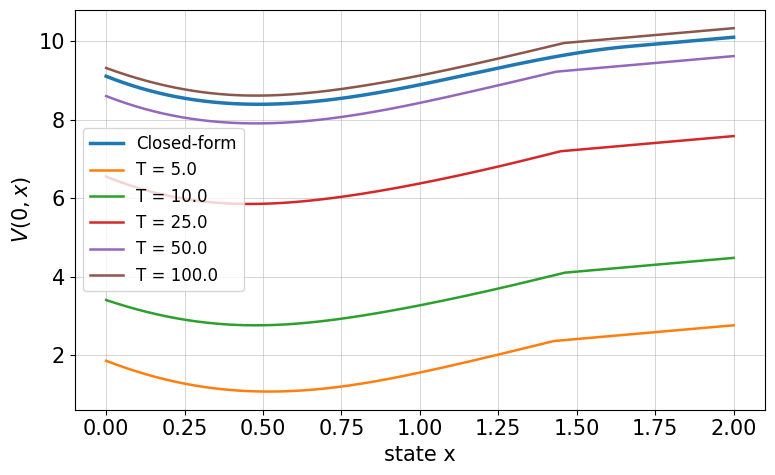

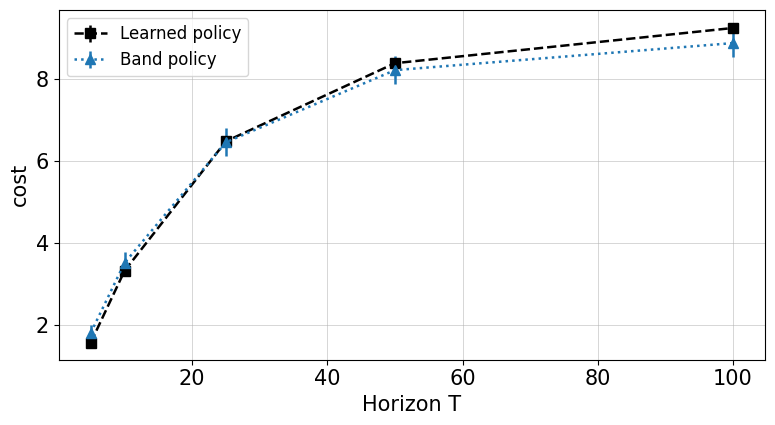

In [18]:
results = all_results_loaded
n_sim_eval = 500

torch.set_default_dtype(torch.float64)

# ============================================================
# 0) DESIGN PARAMETERS FOR FIGURES
# ============================================================
FIG_WIDTH  = 8
FIG_HEIGHT = 5

FONTSIZE_LABELS = 15
FONTSIZE_TICKS  = 15
FONTSIZE_LEGEND = 12
LINEWIDTH_MAIN  = 2.5
LINEWIDTH_SEC   = 1.8
MARKERSIZE      = 7

plt.rcParams.update({
    "font.size": FONTSIZE_TICKS,
    "axes.labelsize": FONTSIZE_LABELS,
    "xtick.labelsize": FONTSIZE_TICKS,
    "ytick.labelsize": FONTSIZE_TICKS,
    "legend.fontsize": FONTSIZE_LEGEND,
    "axes.titlesize": FONTSIZE_LABELS,
})

# ============================================================
# 1) Recover ND harvesting parameters and build ψ_exact on the diagonal
# ============================================================
if len(results) == 0:
    raise RuntimeError("results is empty. Run the training cell first.")

cfg0 = results[0]["cfg"]
hp0  = cfg0.harvesting               # HarvestingParamsND
d    = hp0.state_dim                 # ND dimension

# Extract scalar parameters from the 0-th coordinate (they are replicated)
mu_1d    = float(hp0.mu[0].item())
sigma_1d = float(hp0.sigma[0].item())
alpha_1d = float(hp0.alpha[0].item())
x0_1d    = float(hp0.x0[0].item())
lam_1d   = float(hp0.lam[0].item())
c_1d     = float(hp0.c[0].item())
rho_1d   = float(hp0.rho)

# Closed-form 1D band-policy value function ψ^1D
psi_1d, zeta_star_1d, psi_params_1d = solve_psi_general(
    mu=mu_1d,
    sigma=sigma_1d,
    rho=rho_1d,
    alpha=alpha_1d,
    x0=x0_1d,
    lam=lam_1d,
    c=c_1d,
)
print("Closed-form psi^1D(1) =", psi_1d(torch.tensor([1.0])).item())
print(f"ND dimension d = {d} -> ψ^ND(x,...,x) = d * ψ^1D(x)")

# For ND on the diagonal (x,...,x), ψ^ND(x) = d * ψ^1D(x)
def psi_nd_diag(x: torch.Tensor) -> torch.Tensor:
    """
    Closed-form ND value on the diagonal (x,...,x).
    Input x: [N] or [N,1].
    Returns: [N], equal to d * ψ^1D(x_scalar).
    """
    x_flat = x.view(-1)
    return d * psi_1d(x_flat)

# Parameters for MC band-policy ND
n_sim_band   = 10
dt_fine_band = 2e-3
device = cfg0.device

# ------------------------------------------------------------
# Common scalar x-grid (diagonal slice)
# ------------------------------------------------------------
x_plot = np.linspace(0.0, 2.0, 600)
x_plot_torch = torch.from_numpy(x_plot)

# Closed-form ψ^ND on this grid (diagonal)
psi_plot = psi_nd_diag(x_plot_torch).detach().cpu().numpy()

# ============================================================
# 2) For each experiment in results: MC band-policy ND on [0,T]
#    ψ^ND is already evaluated on x_plot (diagonal)
# ============================================================
for res in results:

    T_val = res["T"] if "T" in res else None
    # Stocke ψ^ND(x) (identique pour tout T, dépend seulement de paramètres et de d)
    res["psi_nd_diag"] = psi_plot.copy()

    # MC under ND band-policy starting from x_init = 1 on each coord
    sim_band_nd = simulate_band_policy_nd(
        mu=mu_1d,
        sigma=sigma_1d,
        rho=rho_1d,
        alpha=alpha_1d,
        x0=x0_1d,
        lam=lam_1d,
        c_f=c_1d,
        d=d,
        x_init=1.0,
        dt=dt_fine_band,
        T_max=T_val,
        n_paths=n_sim_band,
        n_impulses_max=2000,
        seed=1234,
        device=device,
    )

    costs_band_nd = sim_band_nd["COST_total_per_path"].detach().cpu().numpy()
    res["mc_mean_band_nd"] = float(costs_band_nd.mean())
    res["mc_std_band_nd"]  = float(costs_band_nd.std())

    print(
        f"T = {T_val:6.1f} | "
        f"MC ND band = {res['mc_mean_band_nd']:10.6f} ± {res['mc_std_band_nd']:8.6f}"
    )

# ============================================================
# 3) Plot V_hat(0,x_diag) for all T + closed-form ψ^ND(x_diag)
# ============================================================
plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

# Closed-form ψ^ND on diagonal
plt.plot(
    x_plot,
    psi_plot,
    linewidth=LINEWIDTH_MAIN,
    label=rf"Closed-form",
)

# NN curves (interpolation sur le même x_plot, en assumant que res["x"]
# est le scalaire de la diagonale utilisé pour V(0,(x,...,x)))
for res in results:
    V_interp = np.interp(x_plot, res["x"], res["V"])
    label_T = f"T = {res['T']}" if "T" in res else "T (?)"
    plt.plot(
        x_plot,
        V_interp,
        linewidth=LINEWIDTH_SEC,
        label=label_T,
    )

plt.xlabel("state x")
plt.ylabel(r"$V(0,x)$")
plt.grid(True, linewidth=0.6, alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"unlimited_impulses_harvesting_d{d}.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 4) Plot V_hat(0,(1,...,1)) vs MC (NN) vs MC (band-policy ND)
# ============================================================
Ts          = np.array([res["T"] for res in results])
V01_diag    = np.array([res["V0_1"] for res in results])          # V(0,(1,...,1))
MC_NN       = np.array([res["mc_mean_NN"] for res in results])
MC_NN_s     = np.array([res["mc_std_NN"]  for res in results])
MC_band_nd  = np.array([res["mc_mean_band_nd"] for res in results])
MC_band_nd_s= np.array([res["mc_std_band_nd"]  for res in results])

plt.figure(figsize=(FIG_WIDTH, 4.5))

plt.errorbar(
    Ts,
    MC_NN,
    yerr=MC_NN_s / np.sqrt(n_sim_eval),
    fmt="s--",
    markersize=MARKERSIZE,
    linewidth=LINEWIDTH_SEC,
    label="Learned policy",
    color="black",
)

plt.errorbar(
    Ts,
    MC_band_nd,
    yerr=MC_band_nd_s / np.sqrt(n_sim_band),
    fmt="^:",
    markersize=MARKERSIZE,
    linewidth=LINEWIDTH_SEC,
    label="Band policy",
)

plt.xlabel("Horizon T")
plt.ylabel("cost")
plt.grid(True, linewidth=0.6, alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig(f"consistency_harvesting_d{d}.png", dpi=300, bbox_inches="tight")
plt.show()
